# Proyecto Final — Optimización
## Estimación de desempeño individual en sistemas multiagente mediante optimización con restricciones y redes neuronales

**Autores:** Emanuel Michel Naverrete Gomez, Kaleb Alejandro Aguilar Ávila  
**Fecha:** 15 de mayo de 2026

---

# Experimento con optimizador L-BFGS-B

## Contenido del notebook

1. **Importaciones y configuración**
   - Librerías, dispositivo (CPU/GPU), semillas

2. **Carga y preprocesamiento de datos**
   - Fetch de partidos via TBA API (regionales + mundial)
   - Construcción de vectores de representación por robot
   - Partición temporal train / val / test

3. **Construcción del target**
   - Discretización en B=64 bins
   - Soft target gaussiano (σ=3 bins)

4. **Arquitectura del modelo**
   - Embedding por robot (3867->1024->512, BN, ReLU, Dropout)
   - MultiHead Attention (4 heads)
   - Regressor (512->256->64)

5. **Entrenamiento**
   - SGD + momentum, weight decay, ReduceLROnPlateau
   - Función de pérdida: CE + regularización entrópica (\lambda=0.25)

6. **Estimación de EPA (prior Mu0)**
   - Descenso de gradiente proyectado (PGD)
   - L-BFGS-B

7. **Evaluación mundial**
   - 997 partidos · 8 divisiones
   - Métricas: Winner accuracy, RMSE, NRMSE, MAE, Cobertura

---

## Notación del código

### Datos y partición

| Variable | Tipo / Shape | Descripción |
|---|---|---|
| `df_bronce` | DataFrame | Partidos regionales crudos (Score, Alliance, Robots, timestamps) |
| `df_nn_auto` | DataFrame | Partidos con columnas X1_1/2/3 (robots) e Y (auto pts normalizados) |
| `df_nn_tele` | DataFrame | Igual que anterior para puntos teleoperados |
| `CUTOFF` | Timestamp | Fecha de corte train/test = 2026-05-02 (pre-mundial) |
| `df_pre_auto/tele` | DataFrame | Partidos anteriores al mundial (train+val) |

### Vocabulario y representación

| Variable | Tipo / Shape | Descripción |
|---|---|---|
| `todos_robots` | list[str] | Lista ordenada de todos los robots de la temporada |
| `robot2idx` | dict[str→int] | Mapeo robot_key → índice entero |
| `N_ROBOTS` | int = 3658 | Número total de robots únicos |
| `regionals` | list[str] | Lista de torneos regionales únicos |
| `regional2idx` | dict[str→int] | Mapeo event_key → índice entero |
| `N_REGIONALS` | int = 206 | Número de torneos regionales |
| `avg_auto_dict` | dict[str→float] | Promedio de puntos autónomos por robot |
| `var_auto_dict` | dict[str→float] | Varianza de puntos autónomos por robot |
| `win_rate_global` | dict[str→float] | Tasa de victorias histórica por robot |
| `score_tensor` | Tensor (N_ROBOTS, N_REGIONALS) | Puntos promedio normalizados [-1,1] por robot-regional; 0 si no participó |
| `scalar_tensor_auto/tele` | Tensor (N_ROBOTS, 3) | [avg_norm, var_norm, win_rate_norm] por robot |
| `robot_vectors_auto` | Tensor (N_ROBOTS, ROBOT_DIM_AUTO) | Vectores de entrada completos fase autónoma |
| `robot_vectors_tele` | Tensor (N_ROBOTS, ROBOT_DIM_TELE) | Vectores de entrada completos fase teleoperada |
| `ROBOT_DIM_AUTO/TELE` | int = 3867 | N_ROBOTS + N_REGIONALS + 3 |
| `SCALAR_DIM` | int = 3 | Dimensión del bloque estadístico |

### Target y bins

| Variable | Tipo / Shape | Descripción |
|---|---|---|
| `N_BINS` | int = 64 | Número de bins de discretización |
| `SIGMA_BIN` | int = 3 | Suavidad del soft target en bins |
| `LAMBDA_H` | float = 0.25 | Peso del término de entropía en la pérdida |
| `soft_targets` | Tensor (64, 64) | Tabla precomputada de soft targets; fila k = distribución centrada en bin k |
| `target_max_auto/tele` | float | Puntaje máximo observado (para desnormalizar) |

### Entrenamiento

| Variable | Tipo / Shape | Descripción |
|---|---|---|
| `BATCH_SIZE` | int = 256 | Tamaño de batch |
| `N_EPOCHS` | int = 30 | Épocas de entrenamiento |
| `train_sampler` | WeightedRandomSampler | Muestras ponderadas por recencia temporal |
| `model_auto/tele` | AllianceScoreNet | Modelo para fase autónoma / teleoperada |
| `optimizer` | SGD | momentum=0.9, lr=3e-4, weight_decay=1e-3 |
| `scheduler` | ReduceLROnPlateau | patience=5, factor=0.5 |
| `criterion` | CEEntropyLoss | CE + λ_H · H(p̂) |


## Resultados principales

| Modelo           | Accuracy | RMSE  |
|------------------|----------|-------|
| PGD + Atención   | 0.8020   | 93.32 |
| LBFGS + Atención | 0.8000   | 93.81 |
| Baseline avg/3   | 0.7678   | 178.99|

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from collections import defaultdict, Counter
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import minimize
from scipy.spatial.distance import cdist
import warnings
warnings.filterwarnings('ignore')

np.set_printoptions(suppress=True, precision=3)
pd.set_option('display.float_format', '{:.3f}'.format)

In [ ]:
df_bronce = pd.read_csv('df_concatenado.csv')

In [ ]:
df_bronce

,actual_time,EventKey,Match,Alliance,Robot1,Robot2,Robot3,totalAutoPoints,totalTeleopPoints,endGameRobot1,endGameRobot2,endGameRobot3,Score,source_file
0,2026-04-10 14:59:01,2026sccmp,1,red,3490,10231,7085,17,122,NaN,NaN,NaN,139,Data2026sccmp.csv
1,2026-04-10 14:59:01,2026sccmp,1,blue,1287,10388,10367,33,119,NaN,NaN,NaN,152,Data2026sccmp.csv
2,2026-04-10 15:12:32,2026sccmp,2,red,1102,8575,8137,40,161,NaN,NaN,NaN,201,Data2026sccmp.csv
3,2026-04-10 15:12:32,2026sccmp,2,blue,1293,342,4083,17,92,NaN,NaN,NaN,109,Data2026sccmp.csv
4,2026-04-10 15:21:32,2026sccmp,3,red,9315,1758,4451,49,216,NaN,NaN,NaN,265,Data2026sccmp.csv
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30085,2026-04-04 16:52:31,2026wilax,66,blue,4054,135,5019,16,23,NaN,NaN,NaN,39,Data2026wilax.csv
30086,2026-04-04 17:00:29,2026wilax,67,red,706,3692,930,11,101,NaN,NaN,NaN,112,Data2026wilax.csv
30087,2026-04-04 17:00:29,2026wilax,67,blue,8024,8744,2194,59,64,NaN,NaN,NaN,123,Data2026wilax.csv
30088,2026-04-04 17:10:10,2026wilax,68,red,4531,6574,171,28,248,NaN,NaN,NaN,276,Data2026wilax.csv


In [ ]:
# Normalizar el score (0 = 0, 1 = max score global)
max_score = df_bronce['Score'].max()
df_bronce['Score_norm'] = df_bronce['Score'] / max_score

# df_nn_auto
df_nn_auto = df_bronce[['actual_time', 'EventKey', 'Match', 'Alliance',
                         'Robot1', 'Robot2', 'Robot3',
                         'totalAutoPoints', 'Score_norm']].copy()

df_nn_auto.columns = ['actual_time', 'EventKey', 'match', 'alliance',
                      'X1_1', 'X1_2', 'X1_3', 'Y_auto', 'Y']

# df_nn_tele
df_nn_tele = df_bronce[['actual_time', 'EventKey', 'Match', 'Alliance',
                         'Robot1', 'Robot2', 'Robot3',
                         'totalTeleopPoints', 'Score_norm']].copy()

df_nn_tele.columns = ['actual_time', 'EventKey', 'match', 'alliance',
                      'X1_1', 'X1_2', 'X1_3', 'Y_tele', 'Y']

CUTOFF = pd.Timestamp('2026-05-02')

df_nn_auto['actual_time'] = pd.to_datetime(df_nn_auto['actual_time'])
df_nn_tele['actual_time'] = pd.to_datetime(df_nn_tele['actual_time'])

mask_pre = df_nn_auto['actual_time'] < CUTOFF

df_pre_bronce   = df_bronce[mask_pre].sort_values(by='actual_time').reset_index(drop=True)
df_pre_auto     = df_nn_auto[mask_pre].reset_index(drop=True)
df_pre_tele     = df_nn_tele[mask_pre].reset_index(drop=True)


print(f'Pre-mundial : {len(df_pre_auto)} filas | eventos: {df_pre_auto["EventKey"].nunique()}')

Pre-mundial : 30058 filas | eventos: 206


In [ ]:
df_pre_auto

,actual_time,EventKey,match,alliance,X1_1,X1_2,X1_3,Y_auto,Y
0,2026-04-10 14:59:01,2026sccmp,1,red,3490,10231,7085,17,0.152
1,2026-04-10 14:59:01,2026sccmp,1,blue,1287,10388,10367,33,0.166
2,2026-04-10 15:12:32,2026sccmp,2,red,1102,8575,8137,40,0.219
3,2026-04-10 15:12:32,2026sccmp,2,blue,1293,342,4083,17,0.119
4,2026-04-10 15:21:32,2026sccmp,3,red,9315,1758,4451,49,0.289
...,...,...,...,...,...,...,...,...,...
30053,2026-04-04 16:52:31,2026wilax,66,blue,4054,135,5019,16,0.043
30054,2026-04-04 17:00:29,2026wilax,67,red,706,3692,930,11,0.122
30055,2026-04-04 17:00:29,2026wilax,67,blue,8024,8744,2194,59,0.134
30056,2026-04-04 17:10:10,2026wilax,68,red,4531,6574,171,28,0.301


In [ ]:
# VOCABULARIO (el mismo para auto y tele)

todos_robots = sorted(pd.unique(df_nn_auto[['X1_1','X1_2','X1_3']].values.ravel()))
robot2idx    = {r: i for i, r in enumerate(todos_robots)}
N_ROBOTS     = len(todos_robots)

regionals    = sorted(pd.unique(df_nn_auto['EventKey'].values))
regional2idx = {e: i for i, e in enumerate(regionals)}
N_REGIONALS  = len(regionals)

print(f'Robots únicos:     {N_ROBOTS}')
print(f'Regionales únicos: {N_REGIONALS}')


Robots únicos:     3658
Regionales únicos: 207


In [ ]:
# STATS POR ROBOT desde df_bronce (fuente única de verdad)

def build_robot_stats(df_src, col_pts):
    """avg, var de col_pts por robot a partir de df_bronce."""
    df_long = pd.concat([
        df_src[['Robot1', col_pts]].rename(columns={'Robot1': 'robot'}),
        df_src[['Robot2', col_pts]].rename(columns={'Robot2': 'robot'}),
        df_src[['Robot3', col_pts]].rename(columns={'Robot3': 'robot'}),
    ], ignore_index=True).dropna(subset=['robot'])
    stats = df_long.groupby('robot')[col_pts].agg(['mean','var']).reset_index()
    stats.columns = ['robot', 'avg', 'var']
    stats['var'] = stats['var'].fillna(0)
    return stats.set_index('robot')['avg'].to_dict(), \
           stats.set_index('robot')['var'].to_dict()

avg_auto_dict,  var_auto_dict  = build_robot_stats(df_pre_bronce, 'totalAutoPoints')
avg_tele_dict,  var_tele_dict  = build_robot_stats(df_pre_bronce, 'totalTeleopPoints')

# WIN RATE — quién tuvo mayor Score en el match (red vs blue)
# se calcula desde df_bronce comparando pares red/blue del mismo match

win_counts_g  = defaultdict(int)
game_counts_g = defaultdict(int)

# emparejar red vs blue por (EventKey, Match)
df_red  = df_bronce[df_bronce['Alliance'] == 'red']
df_blue = df_bronce[df_bronce['Alliance'] == 'blue']
df_matches = df_red.merge(
    df_blue,
    on=['EventKey', 'Match'],
    suffixes=('_red', '_blue')
)

for _, row in df_matches.iterrows():
    red_won  = row['Score_red']  > row['Score_blue']
    blue_won = row['Score_blue'] > row['Score_red']
    for col in ['Robot1_red', 'Robot2_red', 'Robot3_red']:
        r = row[col]
        game_counts_g[r] += 1
        if red_won: win_counts_g[r] += 1
    for col in ['Robot1_blue', 'Robot2_blue', 'Robot3_blue']:
        r = row[col]
        game_counts_g[r] += 1
        if blue_won: win_counts_g[r] += 1

win_rate_global = {r: win_counts_g[r] / game_counts_g[r] for r in game_counts_g}


# NORMALIZACIÓN min/mean/max -> [-1, 1] Para las stats por regional

def normalize_minmeanmax(values_dict, robots):
    vals = np.array([values_dict.get(r, 0.0) for r in robots])
    v_min, v_mean, v_max = vals.min(), vals.mean(), vals.max()
    normalized = np.where(
        vals <= v_mean,
        (vals - v_mean) / max(v_mean - v_min, 1e-8),
        (vals - v_mean) / max(v_max - v_mean, 1e-8)
    )
    return normalized

win_rate_norm   = normalize_minmeanmax(win_rate_global, todos_robots)
avg_auto_norm   = normalize_minmeanmax(avg_auto_dict,   todos_robots)
var_auto_norm   = normalize_minmeanmax(var_auto_dict,   todos_robots)
avg_tele_norm   = normalize_minmeanmax(avg_tele_dict,   todos_robots)
var_tele_norm   = normalize_minmeanmax(var_tele_dict,   todos_robots)

print(f'win_rate_norm  range: [{win_rate_norm.min():.3f},  {win_rate_norm.max():.3f}]')
print(f'avg_auto_norm  range: [{avg_auto_norm.min():.3f},  {avg_auto_norm.max():.3f}]')
print(f'var_auto_norm  range: [{var_auto_norm.min():.3f},  {var_auto_norm.max():.3f}]')
print(f'avg_tele_norm  range: [{avg_tele_norm.min():.3f},  {avg_tele_norm.max():.3f}]')
print(f'var_tele_norm  range: [{var_tele_norm.min():.3f},  {var_tele_norm.max():.3f}]')



# VICTORY SCORES regionales — win_rate por (robot, evento)
# igual en ambos modelos (viene del mismo Score)

robot_wins_r  = defaultdict(int)
robot_games_r = defaultdict(int)

for _, row in df_matches.iterrows():
    event    = row['EventKey']
    red_won  = row['Score_red']  > row['Score_blue']
    blue_won = row['Score_blue'] > row['Score_red']
    for col in ['Robot1_red', 'Robot2_red', 'Robot3_red']:
        r = row[col]
        robot_games_r[(r, event)] += 1
        if red_won: robot_wins_r[(r, event)] += 1
    for col in ['Robot1_blue', 'Robot2_blue', 'Robot3_blue']:
        r = row[col]
        robot_games_r[(r, event)] += 1
        if blue_won: robot_wins_r[(r, event)] += 1

score_matrix = np.zeros((N_ROBOTS, N_REGIONALS), dtype=np.float32)
for (robot, event), games in robot_games_r.items():
    if robot in robot2idx and event in regional2idx:
        wins = robot_wins_r[(robot, event)]
        score_matrix[robot2idx[robot], regional2idx[event]] = (wins / games) * 2 - 1

# normalizar por columna (evento)
for j in range(N_REGIONALS):
    col  = score_matrix[:, j]
    mask = col != 0
    if mask.sum() < 2: continue
    lo, hi = col[mask].min(), col[mask].max()
    if hi > lo:
        score_matrix[mask, j] = (col[mask] - lo) / (hi - lo) * 2 - 1

score_tensor = torch.tensor(score_matrix, dtype=torch.float)
print(f'score_tensor: {score_tensor.shape} | range [{score_tensor.min():.3f}, {score_tensor.max():.3f}]')

win_rate_norm  range: [-1.000,  1.000]
avg_auto_norm  range: [-1.000,  1.000]
var_auto_norm  range: [-1.000,  1.000]
avg_tele_norm  range: [-1.000,  1.000]
var_tele_norm  range: [-1.000,  1.000]
score_tensor: torch.Size([3658, 207]) | range [-1.000, 1.000]


# Robot Representation

In [ ]:

# ROBOT VECTORS AUTO

SCALAR_DIM_AUTO = 3
ROBOT_DIM_AUTO  = N_ROBOTS + N_REGIONALS + SCALAR_DIM_AUTO

scalar_tensor_auto = torch.tensor(
    np.stack([avg_auto_norm, var_auto_norm, win_rate_norm], axis=1),
    dtype=torch.float
)

def build_robot_vector_auto(robot_idx):
    one_hot  = torch.zeros(N_ROBOTS)
    one_hot[robot_idx] = 1.0
    regional = score_tensor[robot_idx]
    scalars  = scalar_tensor_auto[robot_idx]
    return torch.cat([one_hot, regional, scalars])

robot_vectors_auto = torch.stack([build_robot_vector_auto(i) for i in range(N_ROBOTS)])

# ROBOT VECTORS TELE

SCALAR_DIM_TELE = 3
ROBOT_DIM_TELE  = N_ROBOTS + N_REGIONALS + SCALAR_DIM_TELE

scalar_tensor_tele = torch.tensor(
    np.stack([avg_tele_norm, var_tele_norm, win_rate_norm], axis=1),
    dtype=torch.float
)

def build_robot_vector_tele(robot_idx):
    one_hot  = torch.zeros(N_ROBOTS)
    one_hot[robot_idx] = 1.0
    regional = score_tensor[robot_idx]
    scalars  = scalar_tensor_tele[robot_idx]
    return torch.cat([one_hot, regional, scalars])

robot_vectors_tele = torch.stack([build_robot_vector_tele(i) for i in range(N_ROBOTS)])

print(f'ROBOT_DIM_AUTO:     {ROBOT_DIM_AUTO}')
print(f'robot_vectors_auto: {robot_vectors_auto.shape}')
print(f'ROBOT_DIM_TELE:     {ROBOT_DIM_TELE}')
print(f'robot_vectors_tele: {robot_vectors_tele.shape}')

ROBOT_DIM_AUTO:     3868
robot_vectors_auto: torch.Size([3658, 3868])
ROBOT_DIM_TELE:     3868
robot_vectors_tele: torch.Size([3658, 3868])


# Sample Weights

In [ ]:
# =====================================================================
# SPLIT + SAMPLERS
# =====================================================================

# SPLIT 70 / 20 / 10  (igual para auto y tele, mismo random_state)

train_df, temp_df = train_test_split(df_pre_auto.reset_index(drop=True), test_size=1/3, random_state=42)
val_df,   test_df = train_test_split(temp_df,    test_size=1/3, random_state=42)
print(f'Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}')

# SAMPLE WEIGHTS

robot_counts = Counter()
for col in ['X1_1', 'X1_2', 'X1_3']:
    robot_counts.update(df_pre_auto[col].tolist())

timestamps   = pd.to_datetime(df_pre_auto['actual_time']).astype(np.int64).values.astype(np.float64)
t_min, t_max = timestamps.min(), timestamps.max()
t_norm_w     = (timestamps - t_min) / (t_max - t_min + 1e-8)
DECAY        = 3.0
weights_time = np.exp(DECAY * t_norm_w)

def partido_weight(row):
    counts = [robot_counts[row[c]] for c in ['X1_1', 'X1_2', 'X1_3']]
    return float(np.mean(counts))

weights_pop  = np.array([partido_weight(row) for _, row in df_pre_auto.iterrows()])
weights_raw  = weights_pop * weights_time
weights_all  = weights_raw / weights_raw.sum()
train_weights = weights_all[train_df.index]

train_sampler = torch.utils.data.WeightedRandomSampler(
    weights=torch.tensor(train_weights, dtype=torch.float),
    num_samples=len(train_weights),
    replacement=True
)


Train: 20038 | Val: 6680 | Test: 3340


In [ ]:
# =====================================================================
# HIPERPARÁMETROS DE BINS
# =====================================================================

BATCH_SIZE = 256
N_BINS  = 64
LAMBDA_H = 0.25   # peso del término de entropía
SIGMA_BIN = 3  # suavidad de la distribución target sobre bins

target_min_auto = 0
target_max_auto = df_nn_auto['Y'].max()
target_min_tele = 0
target_max_tele = df_nn_tele['Y'].max()

def make_soft_target(bin_idx, n_bins=N_BINS, sigma=SIGMA_BIN):
    """Distribución Gaussian suave centrada en bin_idx."""
    bins = np.arange(n_bins, dtype=np.float32)
    dist = np.exp(-0.5 * ((bins - bin_idx) / sigma) ** 2)
    return dist / dist.sum()

# precomputar las 10 distribuciones posibles (una por bin)
soft_targets = torch.tensor(
    np.stack([make_soft_target(i) for i in range(N_BINS)]),
    dtype=torch.float
)  # (N_BINS, N_BINS)

print(f'soft_targets shape: {soft_targets.shape}')
print(f'soft_targets[5]: {soft_targets[5].numpy().round(3)}')

# =====================================================================
# TARGET AUTO y TELE -> bin index -> soft distribution
# =====================================================================
def scores_to_bin_idx(target_norm_array, n_bins=N_BINS):
    """Convierte target normalizado [0,1] a índice de bin [0, n_bins-1]."""
    idx = np.floor(target_norm_array * n_bins).astype(int)
    return np.clip(idx, 0, n_bins - 1)

# =====================================================================
# DATASET AUTO (actualizado — Y es distribución suave de N_BINS)
# =====================================================================

class AllianceAutoDataset(Dataset):
    def __init__(self, df):
        n = len(df)
        self.x1 = [torch.zeros(n, ROBOT_DIM_AUTO) for _ in range(3)]
        self.Y  = torch.zeros(n, N_BINS)

        for i, (_, row) in enumerate(df.iterrows()):
            r1_ids = [robot2idx[row['X1_1']], robot2idx[row['X1_2']], robot2idx[row['X1_3']]]
            for k, rid in enumerate(r1_ids):
                self.x1[k][i] = robot_vectors_auto[rid]
            pts_norm = row['Y']
            bin_idx  = int(np.clip(np.floor(pts_norm * N_BINS), 0, N_BINS - 1))
            self.Y[i] = soft_targets[bin_idx]

    def __len__(self): return len(self.Y)

    def __getitem__(self, i):
        perm = torch.randperm(3)
        return [self.x1[perm[k]][i] for k in range(3)], self.Y[i]

# =====================================================================
# DATASET TELE (actualizado)
# =====================================================================

class AllianceTeleDataset(Dataset):
    def __init__(self, df):
        n = len(df)
        self.x1 = [torch.zeros(n, ROBOT_DIM_TELE) for _ in range(3)]
        self.Y  = torch.zeros(n, N_BINS)

        for i, (_, row) in enumerate(df.iterrows()):
            r1_ids = [robot2idx[row['X1_1']], robot2idx[row['X1_2']], robot2idx[row['X1_3']]]
            for k, rid in enumerate(r1_ids):
                self.x1[k][i] = robot_vectors_tele[rid]
            pts_norm = row['Y']
            bin_idx  = int(np.clip(np.floor(pts_norm * N_BINS), 0, N_BINS - 1))
            self.Y[i] = soft_targets[bin_idx]

    def __len__(self): return len(self.Y)

    def __getitem__(self, i):
        perm = torch.randperm(3)
        return [self.x1[perm[k]][i] for k in range(3)], self.Y[i]

print('Datasets definidos')

# =====================================================================
# LOSS: CrossEntropy + \lambda * Entropía de la predicción
# =====================================================================

class CEEntropyLoss(nn.Module):
    def __init__(self, lambda_h=LAMBDA_H, eps=1e-8):
        super().__init__()
        self.lambda_h = lambda_h
        self.eps      = eps

    def forward(self, pred_logits, target_dist):
        """
        pred_logits: (batch, N_BINS) — salida del regresor ANTES de Softmax
        target_dist: (batch, N_BINS) — distribución suave normalizada
        """
        pred_prob = torch.softmax(pred_logits, dim=-1)                    # (batch, N_BINS)
        log_pred  = torch.log(pred_prob + self.eps)

        # Cross-Entropy: -Σ target * log(pred)
        ce_loss   = -(target_dist * log_pred).sum(dim=-1).mean()

        # Entropía de la predicción: -Σ pred * log(pred)
        h_pred    = -(pred_prob * log_pred).sum(dim=-1).mean()

        # maximizar entropía = restar su negativo
        loss      = ce_loss - self.lambda_h * h_pred
        return loss, ce_loss, h_pred

criterion = CEEntropyLoss(lambda_h=LAMBDA_H)
print(f'CEEntropyLoss definido | λ={LAMBDA_H} | N_BINS={N_BINS} | σ_bin={SIGMA_BIN}')

# =====================================================================
# ATTENTION SOBRE ALIANZA DE 3 ROBOTS (sin cambios)
# =====================================================================
class AllianceAttention(nn.Module):
    def __init__(self, embed_dim=64, num_heads=3):
        super().__init__()
        self.attn = nn.MultiheadAttention(
            embed_dim=embed_dim, num_heads=num_heads,
            batch_first=True, dropout=0.1
        )
        self.norm = nn.LayerNorm(embed_dim)

    def forward(self, e1, e2, e3):
        seq = torch.stack([e1, e2, e3], dim=1)
        out, weights = self.attn(seq, seq, seq)
        out = self.norm(out + seq)
        return out.mean(dim=1), weights

# =====================================================================
# RED — output cambia a N_BINS logits (Softmax se aplica en la loss)
# =====================================================================
class AllianceScoreNet(nn.Module):
    def __init__(self, robot_dim, hidden_dim=1024, num_heads=4, n_bins=N_BINS):
        super().__init__()
       # embed_dim = hidden_dim // 4  # 64
        embed_dim = 512
        self.encoder = nn.Sequential(
            nn.Linear(robot_dim, 1024),
            nn.BatchNorm1d(1024),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(1024, embed_dim),
            nn.BatchNorm1d(embed_dim),
            nn.ReLU(),
        )

        self.alliance_attn = AllianceAttention(embed_dim=embed_dim, num_heads=num_heads)

        # output: N_BINS
        self.regressor = nn.Sequential(
            nn.Linear(embed_dim, N_BINS),
        )

        self.regressor = nn.Sequential(
            nn.Linear(embed_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, N_BINS),   # (batch, N_BINS)
        )

    def forward(self, x1_robots):
        e1 = [self.encoder(x.float()) for x in x1_robots]
        z1, attn_w = self.alliance_attn(e1[0], e1[1], e1[2])
        return self.regressor(z1), attn_w   # logits, no probabilidades

    def encode_alliance(self, x_robots):
        e = [self.encoder(x.float()) for x in x_robots]
        z, _ = self.alliance_attn(e[0], e[1], e[2])
        return z

    def encode_robot(self, x):
        return self.encoder(x.float())

device     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_auto = AllianceScoreNet(ROBOT_DIM_AUTO).to(device)
model_tele = AllianceScoreNet(ROBOT_DIM_TELE).to(device)

for name, model in [('AUTO', model_auto), ('TELE', model_tele)]:
    total_params = sum(p.numel() for p in model.parameters())
    print(f'Device: {device} | {name} — Parámetros: {total_params:,}')

soft_targets shape: torch.Size([64, 64])
soft_targets[5]: [0.034 0.057 0.083 0.11  0.13  0.137 0.13  0.11  0.083 0.057 0.034 0.019
 0.009 0.004 0.002 0.001 0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.   ]
Datasets definidos
CEEntropyLoss definido | λ=0.25 | N_BINS=64 | σ_bin=3
Device: cuda | AUTO — Parámetros: 5,689,152
Device: cuda | TELE — Parámetros: 5,689,152


In [ ]:
from IPython.display import display, clear_output


# =====================================================================
# FUNCIÓN DE ENTRENAMIENTO GENÉRICA (auto y tele comparten misma lógica)
# =====================================================================

train_loader_auto = DataLoader(AllianceAutoDataset(train_df), batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader_auto   = DataLoader(AllianceAutoDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False)
test_loader_auto  = DataLoader(AllianceAutoDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False)

train_loader_tele = DataLoader(AllianceTeleDataset(train_df), batch_size=BATCH_SIZE, sampler=train_sampler)
val_loader_tele   = DataLoader(AllianceTeleDataset(val_df),   batch_size=BATCH_SIZE, shuffle=False)
test_loader_tele  = DataLoader(AllianceTeleDataset(test_df),  batch_size=BATCH_SIZE, shuffle=False)

x1s, y = next(iter(train_loader_auto))
print(f'y shape: {y.shape}')  # debe ser (256, 10)

def train_model(model, train_loader, val_loader, model_name='model',
                n_epochs=60, lr=3e-4, weight_decay=1e-3, device=device):

    optimizer = torch.optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay, momentum=0.9)
    #optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=5, factor=0.5
    )
    criterion = CEEntropyLoss(lambda_h=LAMBDA_H)

    best_val_loss = float('inf')
    history = {
        'train_loss': [], 'val_loss': [],
        'train_ce':   [], 'val_ce':   [],
        'train_h':    [], 'val_h':    [],
    }

    for epoch in range(n_epochs):
        # train
        model.train()
        train_loss = train_ce = train_h = train_total = 0

        for x1s, y in train_loader:
            x1s = [x.to(device) for x in x1s]
            y   = y.to(device)
            optimizer.zero_grad()
            logits, _ = model(x1s)
            loss, ce, h = criterion(logits, y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            train_loss  += loss.item()
            train_ce    += ce.item()
            train_h     += h.item()
            train_total += 1

        # val
        model.eval()
        val_loss = val_ce = val_h = val_total = 0

        with torch.no_grad():
            for x1s, y in val_loader:
                x1s = [x.to(device) for x in x1s]
                y   = y.to(device)
                logits, _ = model(x1s)
                loss, ce, h = criterion(logits, y)
                val_loss  += loss.item()
                val_ce    += ce.item()
                val_h     += h.item()
                val_total += 1

        # métricas
        tl = train_loss / train_total;  vl = val_loss / val_total
        tc = train_ce   / train_total;  vc = val_ce   / val_total
        th = train_h    / train_total;  vh = val_h    / val_total

        history['train_loss'].append(tl);  history['val_loss'].append(vl)
        history['train_ce'].append(tc);    history['val_ce'].append(vc)
        history['train_h'].append(th);     history['val_h'].append(vh)

        scheduler.step(vl)

        if vl < best_val_loss:
            best_val_loss = vl
            torch.save(model.state_dict(), f'best_{model_name}.pth')
            saved = ' <- guardado'
        else:
            saved = ''

        # plot
        if (epoch + 1) % 5 == 0 or epoch == 0:
            # La figura se crea DENTRO del loop, con datos ya listos.
            # clear_output borra el output anterior de la celda y
            # display renderiza la figura nueva en su lugar.
            fig, axes = plt.subplots(1, 3, figsize=(18, 4))

            axes[0].plot(history['train_loss'], label='train', color='steelblue')
            axes[0].plot(history['val_loss'],   label='val',   color='coral')
            axes[0].set_title('Loss total (CE - λH)')
            axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

            axes[1].plot(history['train_ce'], label='train', color='steelblue')
            axes[1].plot(history['val_ce'],   label='val',   color='coral')
            axes[1].set_title('Cross-Entropy')
            axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

            axes[2].plot(history['train_h'], label='train', color='steelblue')
            axes[2].plot(history['val_h'],   label='val',   color='coral')
            axes[2].set_title('Entropía de pred H(μ̂)')
            axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

            plt.suptitle(f'[{model_name}] Epoch {epoch+1}/{n_epochs} | val_loss={vl:.5f}')
            plt.tight_layout()

            clear_output(wait=True)   # borra el output previo de la celda
            display(fig)              # renderiza la figura con datos reales
            plt.close(fig)            # evita que matplotlib la muestre de nuevo al final

        print(f'[{model_name}] Epoch {epoch+1:03d} | '
              f'loss={tl:.5f}/{vl:.5f} | '
              f'CE={tc:.5f}/{vc:.5f} | '
              f'H={th:.4f}/{vh:.4f}{saved}')

    #  gráfica final con el historial completo
    fig, axes = plt.subplots(1, 3, figsize=(18, 4))

    axes[0].plot(history['train_loss'], label='train', color='steelblue')
    axes[0].plot(history['val_loss'],   label='val',   color='coral')
    axes[0].set_title('Loss total (CE - λH)')
    axes[0].set_xlabel('Epoch'); axes[0].legend(); axes[0].grid(alpha=0.3)

    axes[1].plot(history['train_ce'], label='train', color='steelblue')
    axes[1].plot(history['val_ce'],   label='val',   color='coral')
    axes[1].set_title('Cross-Entropy')
    axes[1].set_xlabel('Epoch'); axes[1].legend(); axes[1].grid(alpha=0.3)

    axes[2].plot(history['train_h'], label='train', color='steelblue')
    axes[2].plot(history['val_h'],   label='val',   color='coral')
    axes[2].set_title('Entropía de pred H(μ̂)')
    axes[2].set_xlabel('Epoch'); axes[2].legend(); axes[2].grid(alpha=0.3)

    plt.suptitle(f'[{model_name}] Entrenamiento completo | mejor val_loss={best_val_loss:.5f}')
    plt.tight_layout()
    clear_output(wait=True)
    display(fig)
    plt.close(fig)

    print(f'\n[{model_name}] Mejor val_loss: {best_val_loss:.5f}')
    return history




y shape: torch.Size([256, 64])


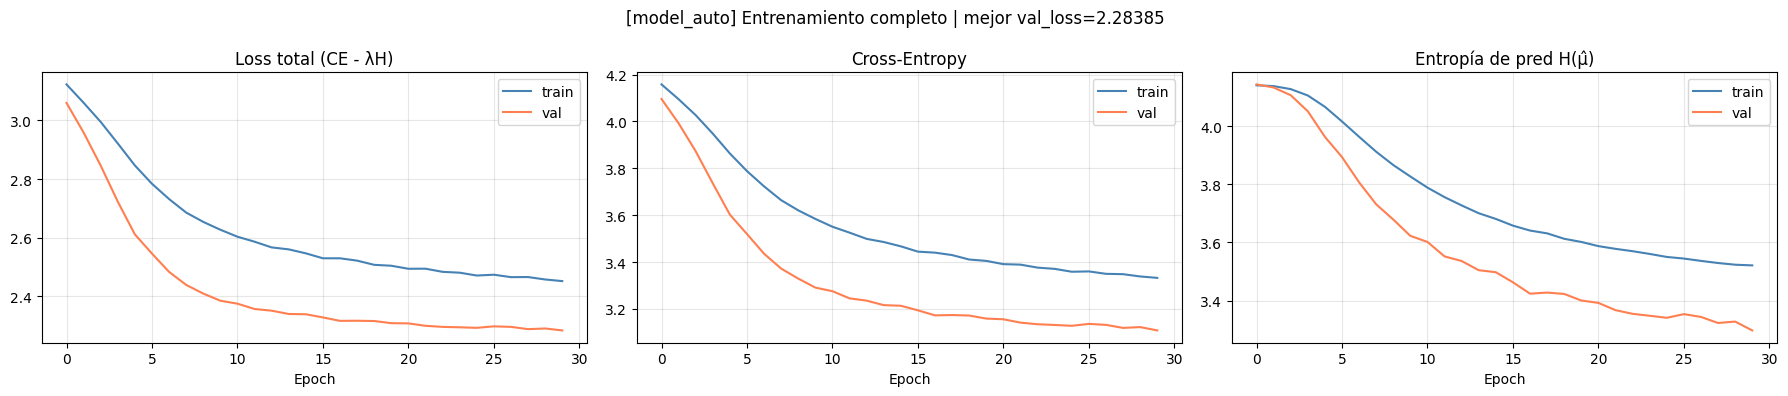


[model_auto] Mejor val_loss: 2.28385


In [ ]:
# =====================================================================
# ENTRENAMIENTO
# =====================================================================

N_EPOCHS = 30

print('=' * 60)
print('ENTRENANDO MODELO AUTO')
print('=' * 60)
history_auto = train_model(
    model_auto, train_loader_auto, val_loader_auto,
    model_name='model_auto', n_epochs=N_EPOCHS
)


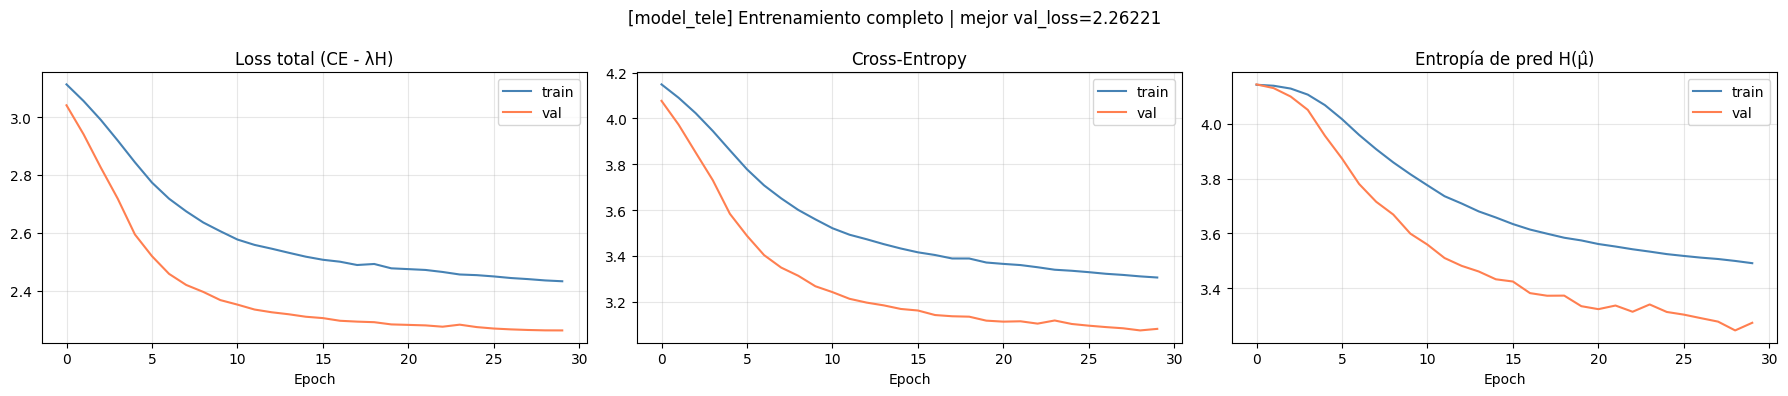


[model_tele] Mejor val_loss: 2.26221


In [ ]:
print('=' * 60)
print('ENTRENANDO MODELO TELE')
print('=' * 60)
history_tele = train_model(
    model_tele, train_loader_tele, val_loader_tele,
    model_name='model_tele', n_epochs=N_EPOCHS
)

In [ ]:
for model, loader, name in [
    (model_auto, train_loader_auto, 'AUTO'),
    (model_tele, train_loader_tele, 'TELE'),
]:
    model.eval()
    x1s, y = next(iter(loader))
    x1s = [x.to(device) for x in x1s]

    with torch.no_grad():
        logits, _ = model(x1s)
        probs = torch.softmax(logits, dim=-1)

    print(f'\n══ {name} — ejemplo [0] ══')
    print(f'  probs: {probs[0].cpu().numpy().round(3)}')


══ AUTO — ejemplo [0] ══
  probs: [0.063 0.078 0.09  0.099 0.101 0.097 0.087 0.074 0.067 0.048 0.041 0.034
 0.023 0.021 0.016 0.012 0.01  0.01  0.005 0.005 0.005 0.002 0.002 0.002
 0.001 0.001 0.001 0.001 0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.    0.
 0.    0.    0.    0.   ]

══ TELE — ejemplo [0] ══
  probs: [0.022 0.028 0.027 0.031 0.031 0.044 0.047 0.047 0.049 0.061 0.056 0.056
 0.057 0.055 0.047 0.039 0.041 0.035 0.033 0.032 0.022 0.021 0.014 0.016
 0.012 0.011 0.008 0.005 0.005 0.004 0.003 0.003 0.002 0.002 0.002 0.002
 0.001 0.001 0.002 0.001 0.001 0.001 0.001 0.002 0.001 0.001 0.001 0.001
 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.001 0.002 0.001 0.001 0.001
 0.001 0.001 0.001 0.001]


In [ ]:
def evaluate_model(model, test_loader, model_name='model', device=device):

    model.load_state_dict(torch.load(f'best_{model_name}.pth', map_location=device))
    model.eval()

    all_preds, all_targets = [], []
    with torch.no_grad():
        for x1s, y in test_loader:
            x1s   = [x.to(device) for x in x1s]
            logits, _ = model(x1s)
            probs = torch.softmax(logits, dim=-1)  # (batch, N_BINS)
            all_preds.append(probs.cpu().numpy())
            all_targets.append(y.numpy())

    preds   = np.concatenate(all_preds)    # (N_test, N_BINS)
    targets = np.concatenate(all_targets)  # (N_test, N_BINS)

    # bin esperado: E[bin] = \sum bin_i * p_i
    bins       = np.arange(N_BINS)
    preds_bin  = (preds   * bins).sum(axis=1)  # (N_test,)
    target_bin = (targets * bins).sum(axis=1)  # (N_test,)

    # métricas en espacio de bins
    residuals = target_bin - preds_bin
    rmse_bins = np.sqrt((residuals**2).mean())
    r2        = 1 - (residuals**2).sum() / ((target_bin - target_bin.mean())**2).sum()

    # KL divergence promedio pred vs target
    eps = 1e-8
    kl  = (targets * np.log((targets + eps) / (preds + eps))).sum(axis=1).mean()

    print(f'[{model_name}] Test RMSE (bins): {rmse_bins:.4f}')
    print(f'[{model_name}] Test R^2  (bins): {r2:.4f}')
    print(f'[{model_name}] Test KL div:      {kl:.6f}')

    return preds, targets, preds_bin, target_bin


preds_auto, targets_auto, preds_bin_auto, target_bin_auto = evaluate_model(
    model_auto, test_loader_auto, model_name='model_auto'
)
preds_tele, targets_tele, preds_bin_tele, target_bin_tele = evaluate_model(
    model_tele, test_loader_tele, model_name='model_tele'
)

[model_auto] Test RMSE (bins): 5.3588
[model_auto] Test R²  (bins): 0.6478
[model_auto] Test KL div:      0.660839
[model_tele] Test RMSE (bins): 5.2248
[model_tele] Test R²  (bins): 0.6652
[model_tele] Test KL div:      0.634197


# Módulo 2. Estimador

In [ ]:
from scipy.sparse import lil_matrix, csr_matrix, block_diag,vstack
from scipy.optimize import minimize

# =====================================================================
# HIPERPARÁMETROS POR MODELO
# =====================================================================
BAYES_PARAMS = {
    'model_auto': {'q': 0.75, 'alpha_ridge': 2.5},
    'model_tele': {'q': 0.75, 'alpha_ridge': 1.5},
}

def run_bayesian_global_solver(model, robot_vectors, robot2idx, todos_robots,
                                avg_dict, var_dict, win_rate_global,
                                df_scores, target_min, target_max,
                                model_name='model', device=device):
    from scipy.sparse import lil_matrix, csr_matrix, block_diag

    q           = BAYES_PARAMS[model_name]['q']
    alpha_ridge = BAYES_PARAMS[model_name]['alpha_ridge']

    # prior de la red
    model.load_state_dict(torch.load(f'best_{model_name}.pth', map_location=device))
    model.eval()

    mu0_norm = np.zeros(len(todos_robots))
    BATCH    = 256
    with torch.no_grad():
        for start in range(0, len(todos_robots), BATCH):
            end  = min(start + BATCH, len(todos_robots))
            vecs = robot_vectors[start:end].to(device)
            logits, _ = model([vecs, vecs, vecs])
            probs = torch.softmax(logits, dim=-1).cpu().numpy()
            bins  = np.arange(N_BINS)
            mu0_norm[start:end] = (probs * bins).sum(axis=1) / (N_BINS - 1)

    mu0  = mu0_norm * (target_max - target_min) + target_min
    tau2 = np.array([var_dict.get(r, 1.0) / 9.0 for r in todos_robots])
    tau2 = np.maximum(tau2, 1.0)

    col_pts        = 'totalAutoPoints' if 'auto' in model_name else 'totalTeleopPoints'
    regionals_list = sorted(df_scores['EventKey'].unique())

    # construir block_diag
    all_A_blocks  = []
    all_Y         = []
    robot_order   = []
    regional_meta = []

    for REGIONAL in regionals_list:
        df_reg = df_scores[df_scores['EventKey'] == REGIONAL].reset_index(drop=True)
        if len(df_reg) < 3:
            continue

        robots_reg = sorted({r for col in ['Robot1','Robot2','Robot3']
                              for r in df_reg[col].tolist()
                              if pd.notna(r) and r in robot2idx})
        if not robots_reg:
            continue

        local_idx = {r: i for i, r in enumerate(robots_reg)}
        n_m, n_r  = len(df_reg), len(robots_reg)

        A_block = lil_matrix((n_m, n_r), dtype=np.float64)
        Y_block = df_reg[col_pts].values.astype(np.float64)
        for i, row in df_reg.iterrows():
            for col in ['Robot1','Robot2','Robot3']:
                r = row[col]
                if pd.notna(r) and r in local_idx:
                    A_block[i, local_idx[r]] = 1.0

        offset = len(robot_order)
        all_A_blocks.append(csr_matrix(A_block))
        all_Y.extend(Y_block.tolist())
        for r in robots_reg:
            robot_order.append((REGIONAL, r, robot2idx[r]))
        regional_meta.append({
            'regional':  REGIONAL,
            'n_matches': n_m,
            'n_robots':  n_r,
            'slice':     slice(offset, offset + n_r),
            'Y':         Y_block,
            'A':         csr_matrix(A_block),
        })

    A_big    = block_diag(all_A_blocks, format='csr')
    Y_big    = np.array(all_Y, dtype=np.float64)
    mu0_big  = np.array([mu0[j]  for _, _, j in robot_order])
    tau2_big = np.array([tau2[j] for _, _, j in robot_order])
    prec_big = (1.0 / tau2_big) * alpha_ridge

    print(f'A_big: {A_big.shape} | entradas: {len(robot_order)}')

    def loss_and_grad(x):
        res      = Y_big - A_big @ x
        neg_mask = (res < 0).astype(np.float64)
        loss     = np.dot(res, q - neg_mask) + 0.5 * np.dot(prec_big, (x - mu0_big)**2)
        grad     = -A_big.T @ (q - neg_mask) + prec_big * (x - mu0_big)
        return loss, grad

    result = minimize(
        loss_and_grad,
        x0      = np.clip(mu0_big, 0, None),
        method  = 'L-BFGS-B',
        jac     = True,
        bounds  = [(0.0, None)] * len(robot_order),
        options = {'maxiter': 5000, 'ftol': 1e-10, 'gtol': 1e-7},
    )

    print(f'Convergió: {result.success} | iters={result.nit} | {result.message}')

    X_map    = result.x
    std_post = np.sqrt(1.0 / prec_big)
    ic_lo    = np.maximum(X_map - 1.96 * std_post, 0)
    ic_hi    = X_map + 1.96 * std_post

    # reconstruir por regional
    all_results = []
    for meta in regional_meta:
        sl         = meta['slice']
        X_reg      = X_map[sl]
        Y_reg      = meta['Y']
        A_reg      = meta['A']
        robots_reg = [robot_order[sl.start + j][1] for j in range(meta['n_robots'])]

        residuals = Y_reg - A_reg @ X_reg
        r2   = 1 - (residuals**2).sum() / ((Y_reg - Y_reg.mean())**2).sum() if Y_reg.std() > 0 else 0
        rmse = np.sqrt((residuals**2).mean())

        print(f'[{meta["regional"]}] q={q} | α={alpha_ridge} | robots={meta["n_robots"]} | '
              f'RMSE={rmse:.2f} | R²={r2:.4f} | EPA=0: {(X_reg == 0.0).sum()}')

        for j, robot in enumerate(robots_reg):
            g = sl.start + j
            all_results.append({
                'EventKey':  meta['regional'],
                'robot':     str(robot),
                'EPA_map':   X_map[g],
                'EPA_lo':    ic_lo[g],
                'EPA_hi':    ic_hi[g],
                'std_post':  std_post[g],
                'mu0':       mu0_big[g],
                'tau':       np.sqrt(tau2_big[g]),
                'win_rate':  win_rate_global.get(robot, 0.0),
                'avg_pts':   avg_dict.get(robot, 0.0) / 3,
                'rmse_reg':  rmse,
                'r2_reg':    r2,
                'n_matches': meta['n_matches'],
                'EPA_zero':  int(X_map[g] == 0.0),
            })

    df_epa = pd.DataFrame(all_results)
    df_epa.to_csv(f'epa_bayesiano_all_{model_name}.csv', index=False)
    print(f'\nGuardado: epa_bayesiano_all_{model_name}.csv')
    print(f'Total filas: {len(df_epa)} | Regionales: {df_epa["EventKey"].nunique()}')

    df_epa.attrs['n_iter']    = result.nit
    df_epa.attrs['converged'] = result.success
    df_epa.attrs['message']   = result.message

    return df_epa


df_epa_auto = run_bayesian_global_solver(
    model=model_auto, robot_vectors=robot_vectors_auto,
    robot2idx=robot2idx, todos_robots=todos_robots,
    avg_dict=avg_auto_dict, var_dict=var_auto_dict,
    win_rate_global=win_rate_global, df_scores=df_pre_bronce,
    target_min=target_min_auto, target_max=target_max_auto,
    model_name='model_auto',
)

df_epa_tele = run_bayesian_global_solver(
    model=model_tele, robot_vectors=robot_vectors_tele,
    robot2idx=robot2idx, todos_robots=todos_robots,
    avg_dict=avg_tele_dict, var_dict=var_tele_dict,
    win_rate_global=win_rate_global, df_scores=df_pre_bronce,
    target_min=target_min_tele, target_max=target_max_tele,
    model_name='model_tele',
)

A_big: (30058, 8102) | entradas: 8102
Convergió: True | iters=1426 | CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
[2026alhu] q=0.75 | α=2.5 | robots=48 | RMSE=13.08 | R²=0.7108 | EPA=0: 0
[2026arc] q=0.75 | α=2.5 | robots=75 | RMSE=24.10 | R²=0.5463 | EPA=0: 0
[2026arli] q=0.75 | α=2.5 | robots=25 | RMSE=14.58 | R²=0.3835 | EPA=0: 0
[2026ausc] q=0.75 | α=2.5 | robots=42 | RMSE=10.33 | R²=0.5349 | EPA=0: 0
[2026azfg] q=0.75 | α=2.5 | robots=55 | RMSE=8.03 | R²=0.6794 | EPA=0: 0
[2026bcvi] q=0.75 | α=2.5 | robots=44 | RMSE=10.83 | R²=0.7264 | EPA=0: 0
[2026brba] q=0.75 | α=2.5 | robots=48 | RMSE=8.51 | R²=0.6792 | EPA=0: 1
[2026brsp] q=0.75 | α=2.5 | robots=49 | RMSE=9.53 | R²=0.6008 | EPA=0: 0
[2026caasv] q=0.75 | α=2.5 | robots=34 | RMSE=14.71 | R²=0.4195 | EPA=0: 0
[2026cacac] q=0.75 | α=2.5 | robots=35 | RMSE=10.31 | R²=0.4992 | EPA=0: 0
[2026caclv] q=0.75 | α=2.5 | robots=26 | RMSE=18.24 | R²=0.6077 | EPA=0: 0
[2026caetb] q=0.75 | α=2.5 | robots=39 | RMSE=12.03 | R²=0.7368 |

# Evaluación Final (Predicción de los partidos del Mundial)

In [ ]:
# =============================
#  SOLVER LBFGS CON X0 = avg/3
# ==============================
# =============================
#  SOLVER LBFGS CON X0 = avg/3
# ==============================

from collections import defaultdict
from scipy.sparse import lil_matrix, csr_matrix

def run_bayesian_avg_prior(todos_robots, robot2idx,
                            avg_dict, var_dict, win_rate_global,
                            df_scores, model_name='model_auto'):

    q           = BAYES_PARAMS[model_name]['q']
    alpha_ridge = BAYES_PARAMS[model_name]['alpha_ridge']
    col_pts     = 'totalAutoPoints' if 'auto' in model_name else 'totalTeleopPoints'

    mu0  = np.array([avg_dict.get(r, 0.0) / 3.0 for r in todos_robots])
    tau2 = np.array([var_dict.get(r, 1.0) / 9.0 for r in todos_robots])
    tau2 = np.maximum(tau2, 1.0)
    prec0 = (1.0 / tau2) * alpha_ridge

    n_robots_global = len(todos_robots)
    regionals_list  = sorted(df_scores['EventKey'].unique())
    all_A_rows      = []
    all_Y           = []
    regional_meta   = []

    for REGIONAL in regionals_list:
        df_reg = df_scores[df_scores['EventKey'] == REGIONAL].reset_index(drop=True)
        if len(df_reg) < 3:
            continue

        robots_reg = sorted({r for col in ['Robot1','Robot2','Robot3']
                              for r in df_reg[col].tolist()
                              if pd.notna(r) and r in robot2idx})
        if not robots_reg:
            continue

        n_m     = len(df_reg)
        Y_block = df_reg[col_pts].values.astype(np.float64)

        A_block = lil_matrix((n_m, n_robots_global), dtype=np.float64)
        for i, row in df_reg.iterrows():
            for col in ['Robot1','Robot2','Robot3']:
                r = row[col]
                if pd.notna(r) and r in robot2idx:
                    A_block[i, robot2idx[r]] = 1.0

        all_A_rows.append(csr_matrix(A_block))
        all_Y.extend(Y_block.tolist())
        regional_meta.append({
            'regional':  REGIONAL,
            'n_matches': n_m,
            'n_robots':  len(robots_reg),
            'robots':    robots_reg,
            'Y':         Y_block,
            'A':         csr_matrix(A_block),
        })

    A_big = vstack(all_A_rows, format='csr')
    Y_big = np.array(all_Y, dtype=np.float64)

    print(f'A_big: {A_big.shape} | robots únicos: {n_robots_global}')

    def loss_and_grad(x):
        res      = Y_big - A_big @ x
        neg_mask = (res < 0).astype(np.float64)
        loss     = np.dot(res, q - neg_mask) + 0.5 * np.dot(prec0, (x - mu0)**2)
        grad     = -A_big.T @ (q - neg_mask) + prec0 * (x - mu0)
        return loss, grad

    result = minimize(loss_and_grad, x0=np.clip(mu0, 0, None),
                      method='L-BFGS-B', jac=True,
                      bounds=[(0.0, None)] * n_robots_global,
                      options={'maxiter': 5000, 'ftol': 1e-10, 'gtol': 1e-7})

    print(f'Convergió: {result.success} | iters={result.nit} | {result.message}')

    X_map    = result.x
    std_post = np.sqrt(1.0 / prec0)
    ic_lo    = np.maximum(X_map - 1.96 * std_post, 0)
    ic_hi    = X_map + 1.96 * std_post

    all_results = []
    for meta in regional_meta:
        robots_reg = meta['robots']
        Y_reg      = meta['Y']
        A_reg      = meta['A']
        X_reg      = np.array([X_map[robot2idx[r]] for r in robots_reg])

        residuals = Y_reg - A_reg @ X_map
        r2   = 1 - (residuals**2).sum() / ((Y_reg - Y_reg.mean())**2).sum() if Y_reg.std() > 0 else 0
        rmse = np.sqrt((residuals**2).mean())

        print(f'[{meta["regional"]}] q={q} | α={alpha_ridge} | robots={meta["n_robots"]} | '
              f'RMSE={rmse:.2f} | R²={r2:.4f} | EPA=0: {(X_reg == 0.0).sum()}')

        for robot in robots_reg:
            j = robot2idx[robot]
            all_results.append({
                'EventKey':  meta['regional'],
                'robot':     str(robot),
                'EPA_map':   X_map[j],
                'EPA_lo':    ic_lo[j],
                'EPA_hi':    ic_hi[j],
                'std_post':  std_post[j],
                'mu0':       mu0[j],
                'tau':       np.sqrt(tau2[j]),
                'win_rate':  win_rate_global.get(robot, 0.0),
                'avg_pts':   avg_dict.get(robot, 0.0) / 3,
                'rmse_reg':  rmse,
                'r2_reg':    r2,
                'n_matches': meta['n_matches'],
                'EPA_zero':  int(X_map[j] == 0.0),
            })

    df_epa = pd.DataFrame(all_results)

    df_epa.attrs['n_iter']    = result.nit
    df_epa.attrs['converged'] = result.success
    df_epa.attrs['message']   = result.message

    return df_epa


df_epa_auto_avg = run_bayesian_avg_prior(
    todos_robots, robot2idx, avg_auto_dict, var_auto_dict,
    win_rate_global, df_pre_bronce, model_name='model_auto')

df_epa_tele_avg = run_bayesian_avg_prior(
    todos_robots, robot2idx, avg_tele_dict, var_tele_dict,
    win_rate_global, df_pre_bronce, model_name='model_tele')

A_big: (30058, 3658) | robots únicos: 3658
Convergió: True | iters=3617 | CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
[2026alhu] q=0.75 | α=2.5 | robots=48 | RMSE=14.87 | R²=0.6260 | EPA=0: 0
[2026arc] q=0.75 | α=2.5 | robots=75 | RMSE=26.31 | R²=0.4592 | EPA=0: 0
[2026arli] q=0.75 | α=2.5 | robots=25 | RMSE=25.12 | R²=-0.8286 | EPA=0: 0
[2026ausc] q=0.75 | α=2.5 | robots=42 | RMSE=11.11 | R²=0.4624 | EPA=0: 1
[2026azfg] q=0.75 | α=2.5 | robots=55 | RMSE=16.38 | R²=-0.3347 | EPA=0: 0
[2026bcvi] q=0.75 | α=2.5 | robots=44 | RMSE=16.83 | R²=0.3386 | EPA=0: 3
[2026brba] q=0.75 | α=2.5 | robots=48 | RMSE=11.58 | R²=0.4059 | EPA=0: 0
[2026brsp] q=0.75 | α=2.5 | robots=49 | RMSE=12.32 | R²=0.3328 | EPA=0: 0
[2026caasv] q=0.75 | α=2.5 | robots=34 | RMSE=15.95 | R²=0.3177 | EPA=0: 0
[2026cacac] q=0.75 | α=2.5 | robots=35 | RMSE=10.33 | R²=0.4976 | EPA=0: 0
[2026caclv] q=0.75 | α=2.5 | robots=26 | RMSE=22.72 | R²=0.3912 | EPA=0: 0
[2026caetb] q=0.75 | α=2.5 | robots=39 | RMSE=11.69 | R

In [ ]:
# =====================================================================
# EVALUACIÓN MUNDIAL — 3 experimentos
# =====================================================================

MUNDIAL_EVENTS = ['2026arc', '2026cur', '2026dal', '2026gal', '2026hop',
                  '2026joh', '2026mil', '2026new']

df_mundial_bronce = df_bronce[df_bronce['EventKey'].isin(MUNDIAL_EVENTS)].reset_index(drop=True)

def build_lookup_global_full(df_a, df_t):
    ea = df_a.groupby('robot').agg(epa_auto=('EPA_map','mean'),
                                    std_auto=('std_post','mean'))
    et = df_t.groupby('robot').agg(epa_tele=('EPA_map','mean'),
                                    std_tele=('std_post','mean'))
    df = pd.concat([ea, et], axis=1).dropna()
    df['epa_total'] = df['epa_auto'] + df['epa_tele']
    df['std_total'] = np.sqrt(df['std_auto']**2 + df['std_tele']**2)
    df.index = df.index.astype(str)
    return df

lookup_net = build_lookup_global_full(df_epa_auto,     df_epa_tele)
lookup_avg = build_lookup_global_full(df_epa_auto_avg, df_epa_tele_avg)
baseline   = {str(r): (avg_auto_dict.get(r,0.0) + avg_tele_dict.get(r,0.0)) / 3.0
              for r in todos_robots}

def alliance_sum(row, cols, lookup, field='epa_total'):
    return sum(lookup.loc[row[c], field]
               if row[c] in lookup.index
               else baseline.get(row[c], 0.0)
               for c in cols)

def alliance_std(row, cols, lookup):
    return sum(
        lookup.loc[row[c], 'std_total']
        if row[c] in lookup.index else 0.0
        for c in cols
    )

# parear red vs blue
df_r = df_mundial_bronce[df_mundial_bronce['Alliance']=='red'].copy()
df_b = df_mundial_bronce[df_mundial_bronce['Alliance']=='blue'].copy()
df_m = df_r.merge(df_b, on=['EventKey','Match'], suffixes=('_red','_blue'))
for col in ['Robot1_red','Robot2_red','Robot3_red',
            'Robot1_blue','Robot2_blue','Robot3_blue']:
    df_m[col] = df_m[col].astype(str)

rcols = ['Robot1_red',  'Robot2_red',  'Robot3_red']
bcols = ['Robot1_blue', 'Robot2_blue', 'Robot3_blue']

for prefix, lookup in [('net', lookup_net), ('avg', lookup_avg)]:
    df_m[f'{prefix}_red']     = df_m.apply(lambda r: alliance_sum(r, rcols, lookup), axis=1)
    df_m[f'{prefix}_blue']    = df_m.apply(lambda r: alliance_sum(r, bcols, lookup), axis=1)
    df_m[f'{prefix}_std_red'] = df_m.apply(lambda r: alliance_std(r, rcols, lookup), axis=1)

df_m['bas_red']  = df_m.apply(lambda r: sum(baseline.get(r[c], 0.0) for c in rcols), axis=1)
df_m['bas_blue'] = df_m.apply(lambda r: sum(baseline.get(r[c], 0.0) for c in bcols), axis=1)

# métricas
def compute_metrics(df, rc, bc, std_col=None):
    rw   = df['Score_red']  > df['Score_blue']
    pw   = df[rc]           > df[bc]
    ties = df['Score_red'] == df['Score_blue']
    acc  = ((rw == pw) & ~ties).sum() / max((~ties).sum(), 1)

    s_real = np.concatenate([df['Score_red'].values, df['Score_blue'].values])
    s_pred = np.concatenate([df[rc].values,          df[bc].values])
    rmse   = np.sqrt(((s_real - s_pred)**2).mean())
    nrmse  = rmse / np.sqrt(s_real.var())

    margin_real = (df['Score_red'] - df['Score_blue']).values
    margin_pred = (df[rc]          - df[bc]).values
    mae_margin  = np.abs(margin_real - margin_pred).mean()

    cobertura = np.nan
    if std_col:
        pred   = df[rc].values
        std    = df[std_col].values
        real   = df['Score_red'].values
        inside = (real >= pred - std) & (real <= pred + std)
        cobertura = inside.mean()

    return acc, rmse, nrmse, mae_margin, cobertura

acc_net, rmse_net, nrmse_net, mae_net, cov_net = compute_metrics(
    df_m, 'net_red', 'net_blue', std_col='net_std_red')
acc_avg, rmse_avg, nrmse_avg, mae_avg, cov_avg = compute_metrics(
    df_m, 'avg_red', 'avg_blue', std_col='avg_std_red')
acc_bas, rmse_bas, nrmse_bas, mae_bas, _       = compute_metrics(
    df_m, 'bas_red', 'bas_blue')

n_partidos   = len(df_m)
n_divisiones = df_m['EventKey'].nunique()
n_iter_auto  = df_epa_auto.attrs.get('n_iter', 'N/A')
n_iter_tele  = df_epa_tele.attrs.get('n_iter', 'N/A')

print(f'\n{"═"*72}')
print(f'  EVALUACIÓN MUNDIAL | {n_partidos} partidos | {n_divisiones} divisiones')
print(f'{"═"*72}')
print(f'  {"Métrica":<22} {"LBFGS+Attention":>16} {"LBFGS+avg/3":>14} {"Baseline (avg/3)":>12}')
print(f'  {"─"*74}')
print(f'  {"Winner accuracy":<22} {acc_net:>16.4f} {acc_avg:>14.4f} {acc_bas:>12.4f}')
print(f'  {"RMSE (pts)":<22} {rmse_net:>16.2f} {rmse_avg:>14.2f} {rmse_bas:>12.2f}')
print(f'  {"NRMSE":<22} {nrmse_net:>16.4f} {nrmse_avg:>14.4f} {nrmse_bas:>12.4f}')
print(f'  {"MAE margen (pts)":<22} {mae_net:>16.2f} {mae_avg:>14.2f} {mae_bas:>12.2f}')
print(f'  {"Cobertura":<22} {cov_net:>16.4f} {cov_avg:>14.4f} {"N/A":>12}')
print(f'  {"─"*74}')
print(f'  {"":22} {"AUTO":>16} {"TELE":>14}')
print(f'  {"Iters (net)":<22} {df_epa_auto.attrs.get("n_iter","N/A"):>16} {df_epa_tele.attrs.get("n_iter","N/A"):>14}')
print(f'  {"Iters (avg)":<22} {df_epa_auto_avg.attrs.get("n_iter","N/A"):>16} {df_epa_tele_avg.attrs.get("n_iter","N/A"):>14}')
print(f'  {"Converged (net)":<22} {str(df_epa_auto.attrs.get("converged","N/A")):>16} {str(df_epa_tele.attrs.get("converged","N/A")):>14}')
print(f'  {"Converged (avg)":<22} {str(df_epa_auto_avg.attrs.get("converged","N/A")):>16} {str(df_epa_tele_avg.attrs.get("converged","N/A")):>14}')
print(f'{"═"*72}')

print(f'\n{"═"*70}')
print(f'  ESTADÍSTICAS DE PREDICCIONES')
print(f'{"═"*70}')
print(f'  {"Predictor":<22} {"mean":>10} {"std":>10} {"delta mean":>10}')
print(f'  {"─"*54}')

real = (df_m['Score_red'].values + df_m['Score_blue'].values) / 2
print(f'  {"Score real":<22} {real.mean():>10.2f} {real.std():>10.2f} {"—":>10}')

for name, rc, bc in [
    ('LBFGS+Attention', 'net_red', 'net_blue'),
    ('LBFGS+avg/3',     'avg_red', 'avg_blue'),
    ('Baseline',        'bas_red', 'bas_blue'),
]:
    vals = (df_m[rc].values + df_m[bc].values) / 2
    delta = vals.mean() - real.mean()
    print(f'  {name:<22} {vals.mean():>10.2f} {vals.std():>10.2f} {delta:>+10.2f}')

print(f'{"═"*70}')


════════════════════════════════════════════════════════════════════════
  EVALUACIÓN MUNDIAL | 997 partidos | 8 divisiones
════════════════════════════════════════════════════════════════════════
  Métrica                 LBFGS+Attention    LBFGS+avg/3 Baseline (avg/3)
  ──────────────────────────────────────────────────────────────────────────
  Winner accuracy                  0.8000         0.7899       0.7678
  RMSE (pts)                        93.79         104.74       178.99
  NRMSE                            0.6484         0.7241       1.2374
  MAE margen (pts)                  95.70          96.00       134.76
  Cobertura                        0.7272         0.6921          N/A
  ──────────────────────────────────────────────────────────────────────────
                                     AUTO           TELE
  Iters (net)                        1426           2131
  Iters (avg)                        3617           5000
  Converged (net)                    True           T

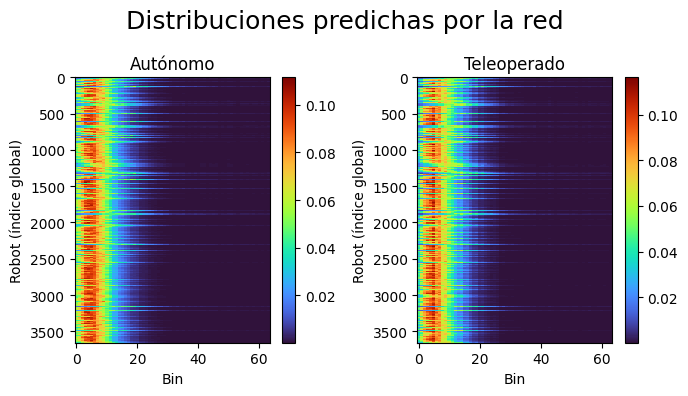

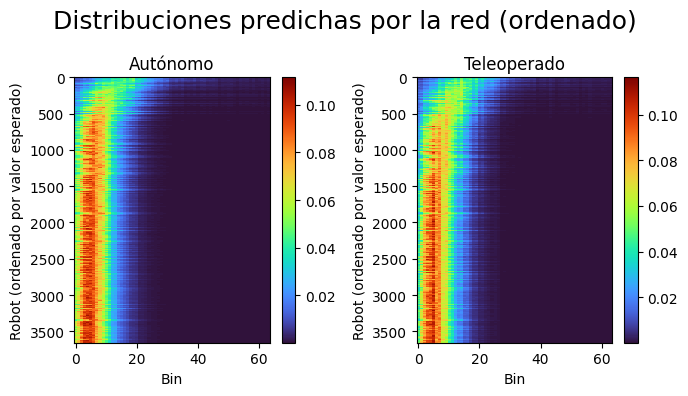

In [ ]:
for ordenado, fname in [(False, 'heatmap_distribuciones.png'),
                         (True,  'heatmap_distribuciones_sorted.png')]:
    fig, axes = plt.subplots(1, 2, figsize=(7, 4))

    for ax, (model, robot_vectors, name) in zip(axes, [
        (model_auto, robot_vectors_auto, 'Autónomo'),
        (model_tele, robot_vectors_tele, 'Teleoperado'),
    ]):
        model.eval()
        mean_vec = robot_vectors.mean(dim=0, keepdim=True)
        embeddings = []
        BATCH = 256
        with torch.no_grad():
            for start in range(0, len(todos_robots), BATCH):
                end      = min(start + BATCH, len(todos_robots))
                vecs     = robot_vectors[start:end].to(device)
                mean_exp = mean_vec.expand(end - start, -1).to(device)
                logits, _ = model([vecs, mean_exp, mean_exp])
                probs = torch.softmax(logits, dim=-1).cpu().numpy()
                embeddings.append(probs)
        emb = np.concatenate(embeddings, axis=0)

        if ordenado:
            epa_order = (df_epa_auto.groupby('robot')['EPA_map'].mean() +
                         df_epa_tele.groupby('robot')['EPA_map'].mean())
            order = epa_order.reindex([str(r) for r in todos_robots]).fillna(0).argsort().values[::-1]
            emb = emb[order]
            ylabel = 'Robot (ordenado por valor esperado)'
        else:
            ylabel = 'Robot (índice global)'

        im = ax.imshow(emb, aspect='auto', cmap='turbo', interpolation='nearest')
        ax.set_title(name)
        ax.set_xlabel('Bin')
        ax.set_ylabel(ylabel)
        plt.colorbar(im, ax=ax)

    titulo = 'Distribuciones predichas por la red (ordenado)' if ordenado else 'Distribuciones predichas por la red'
    plt.suptitle(titulo, fontsize=18)
    plt.tight_layout()
    plt.savefig(fname, dpi=150, bbox_inches='tight')
    plt.show()

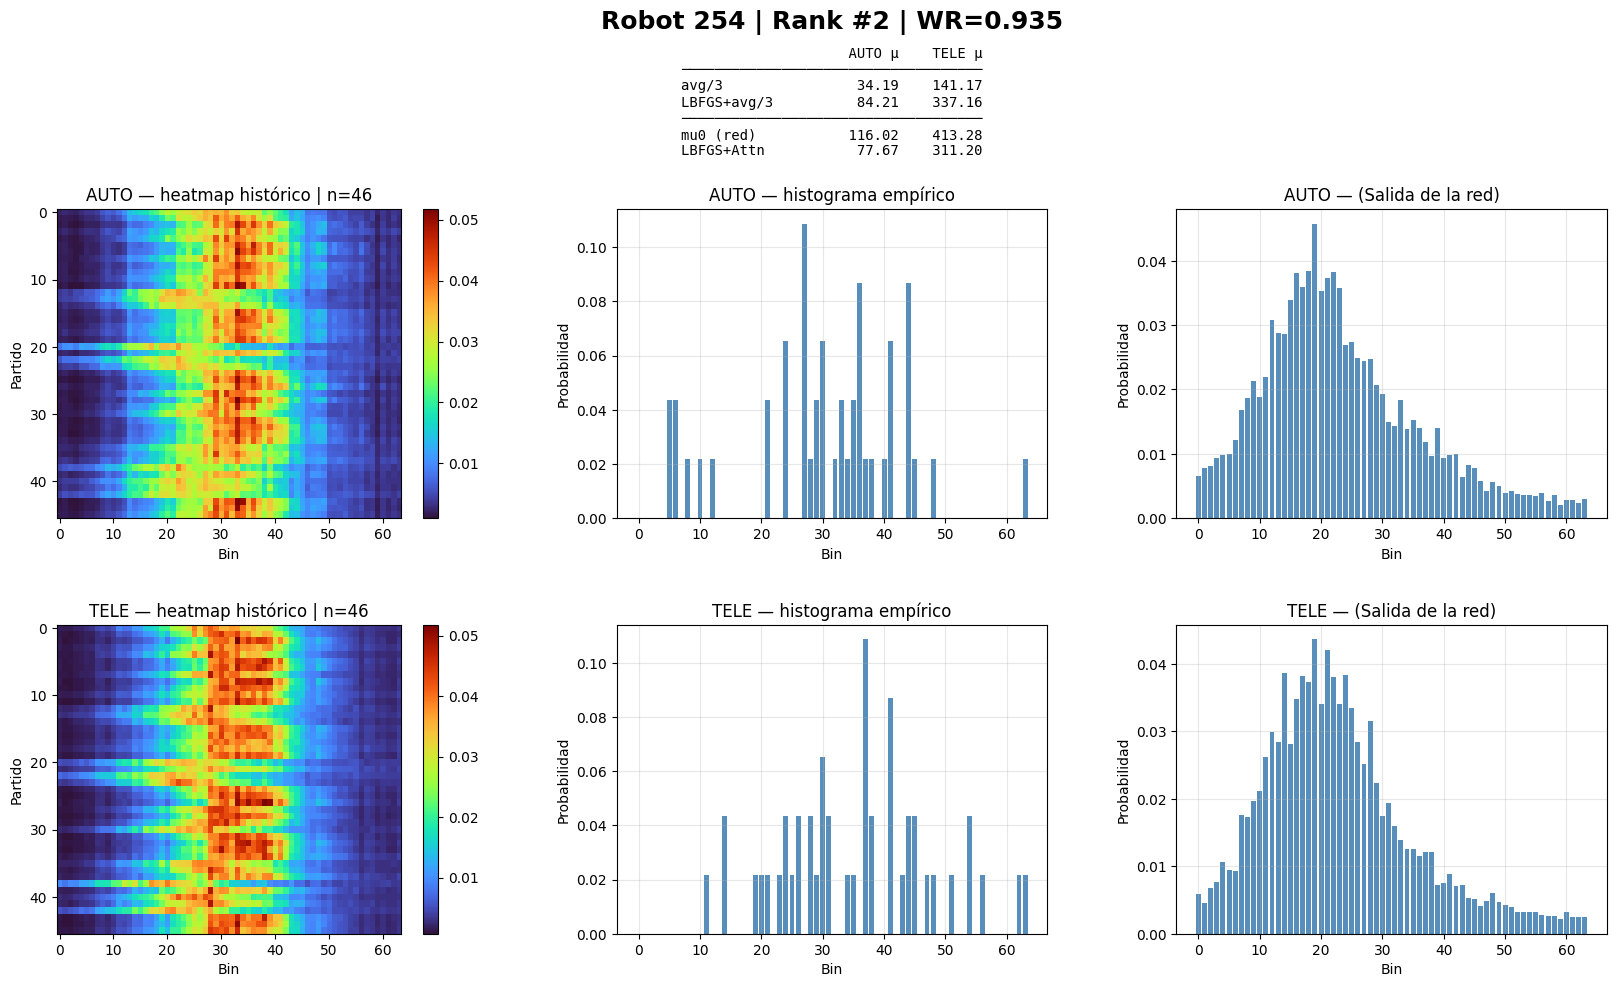

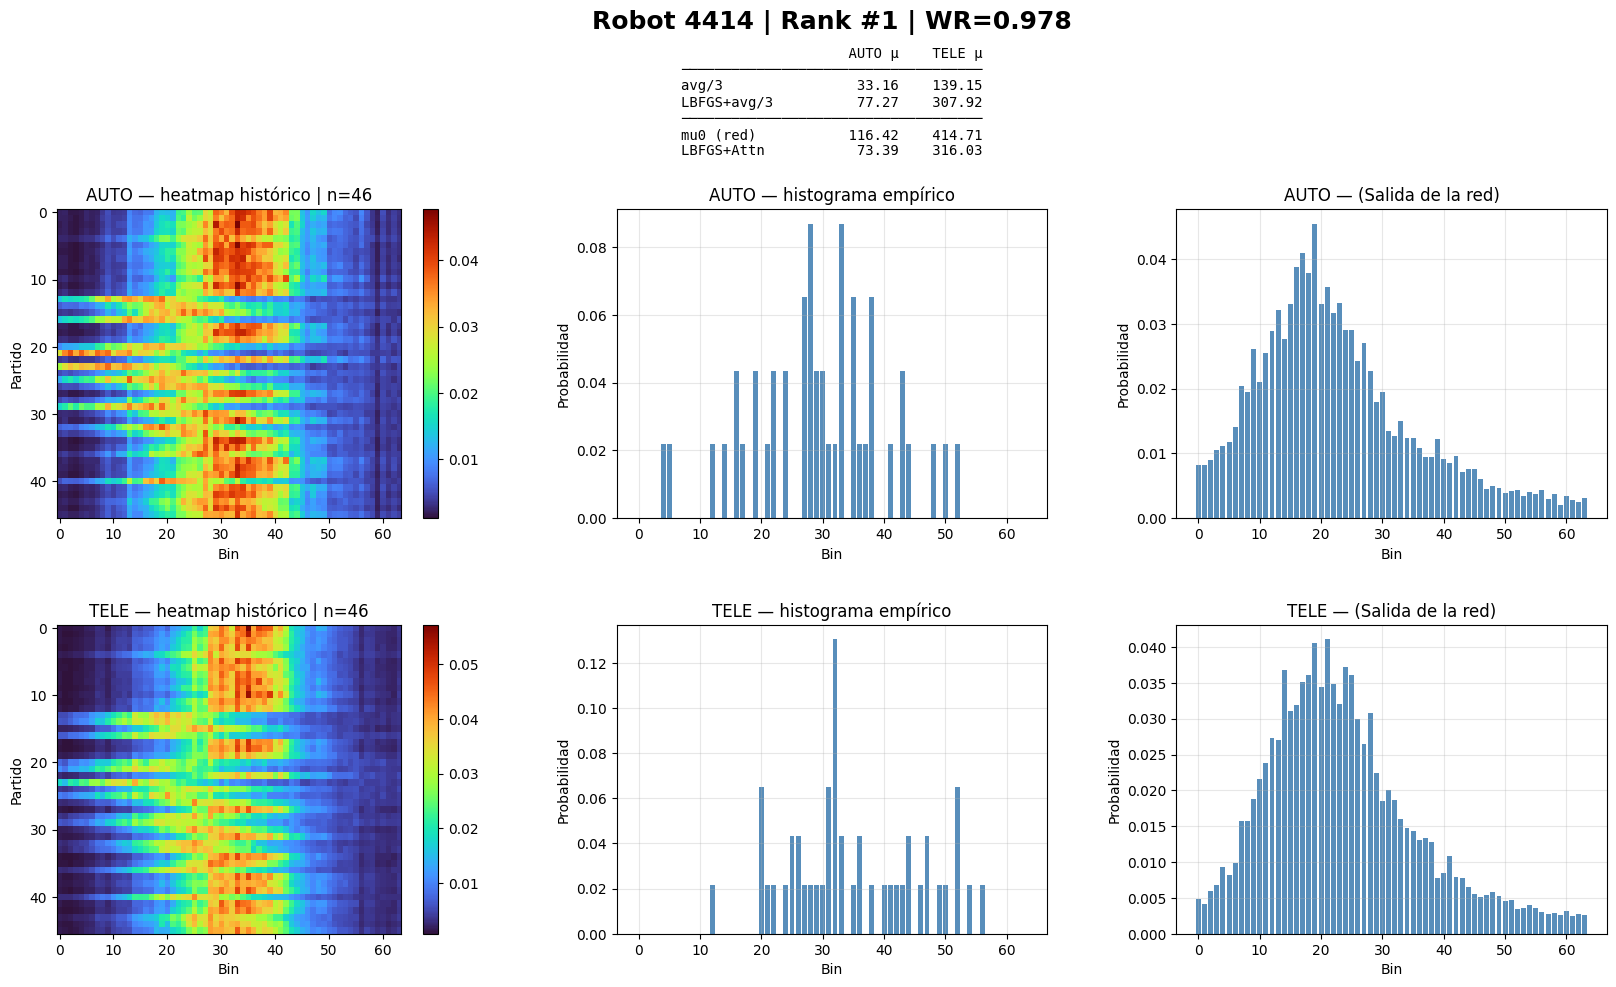

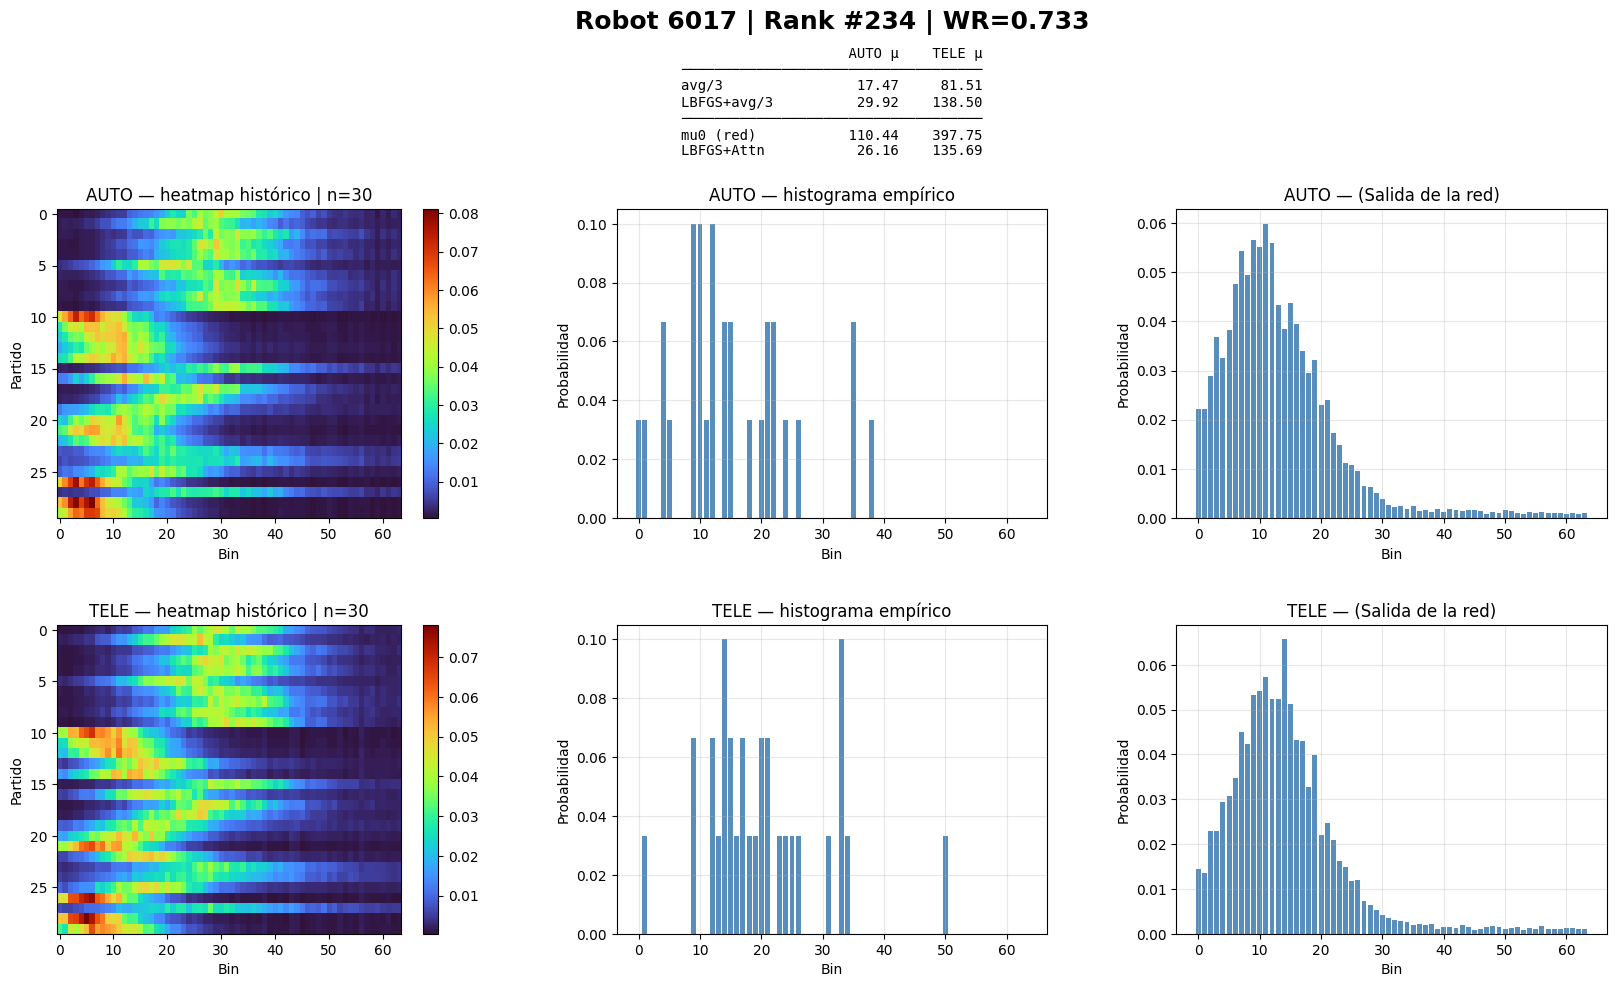

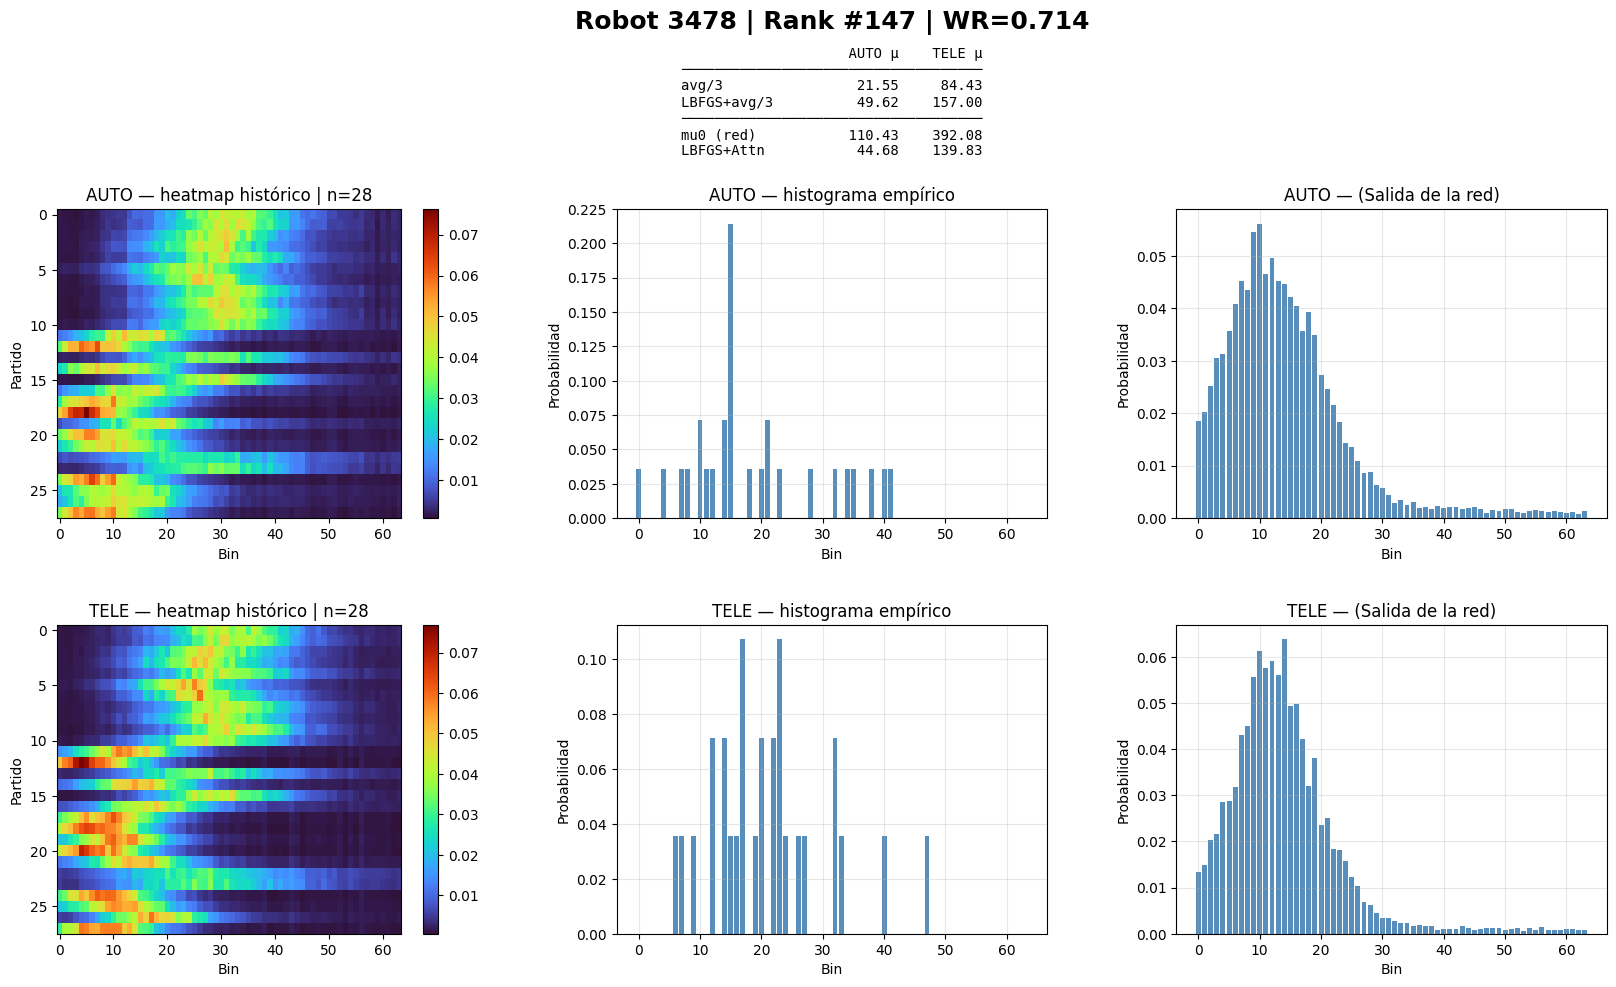

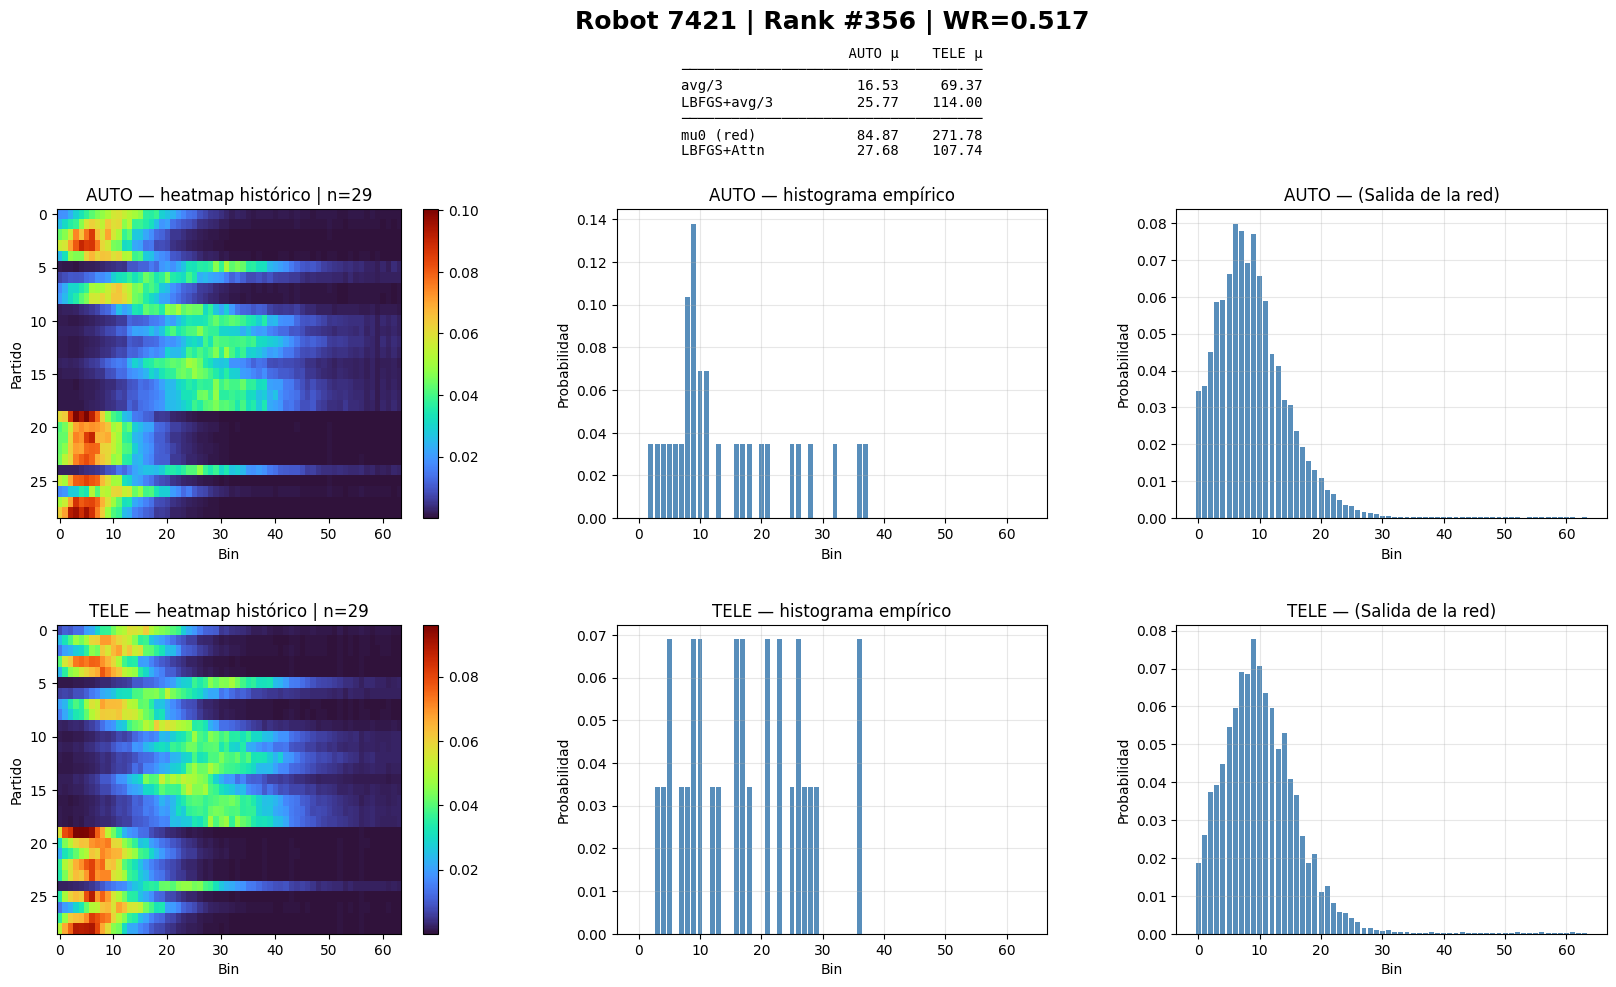

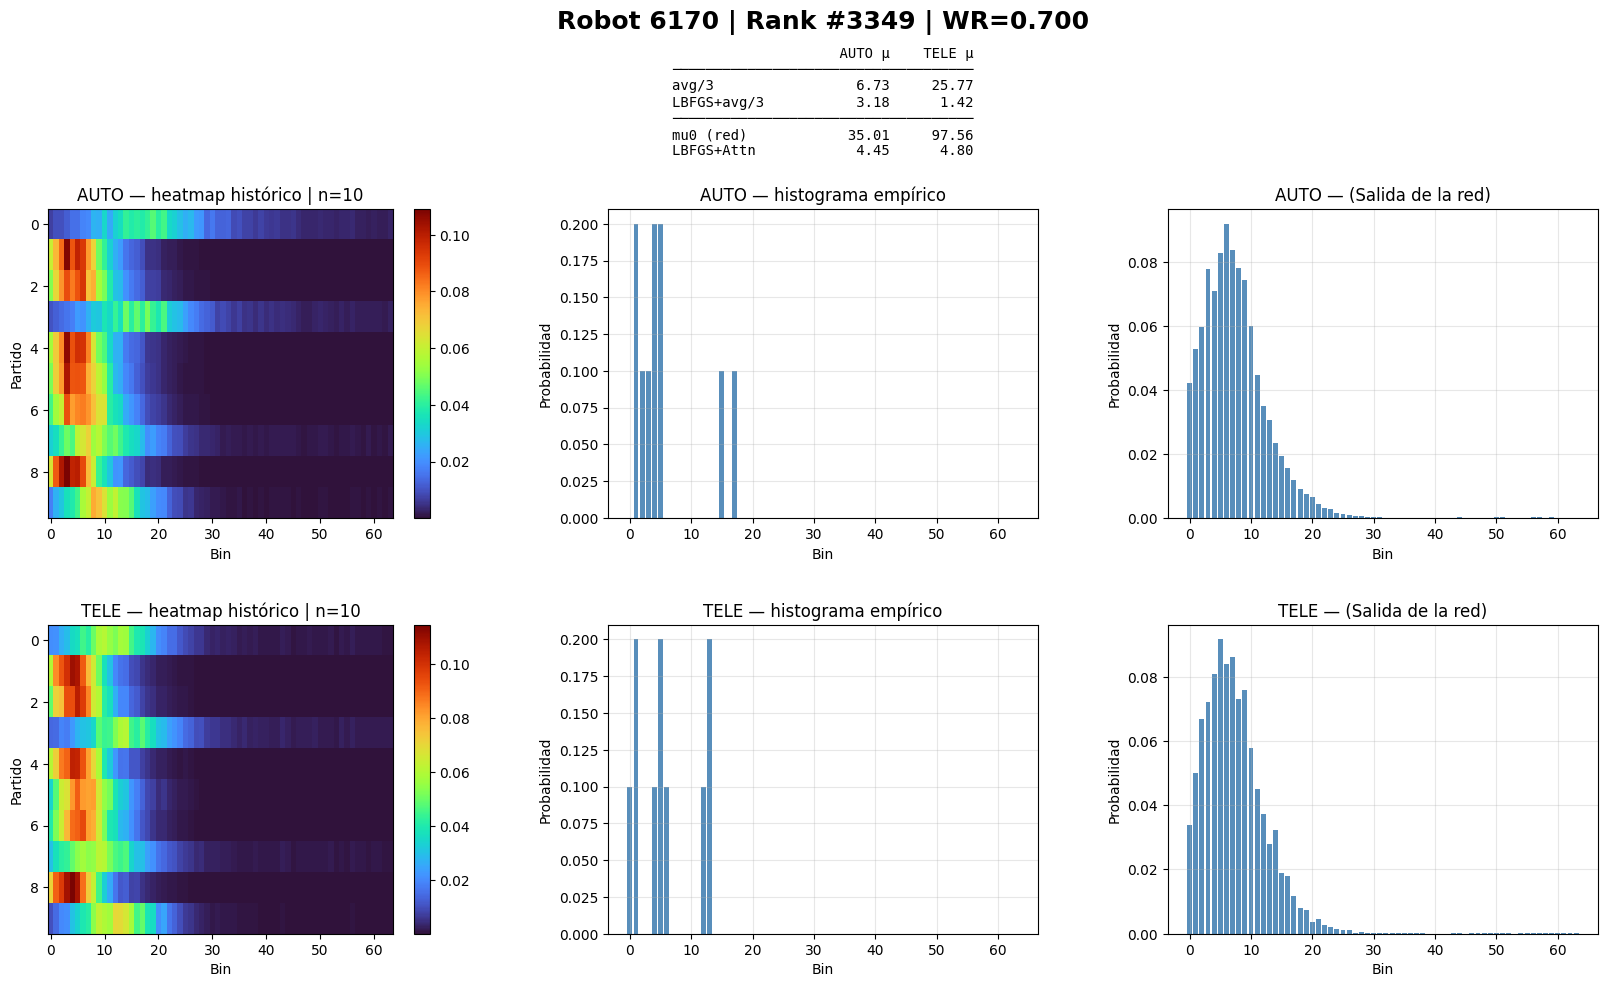

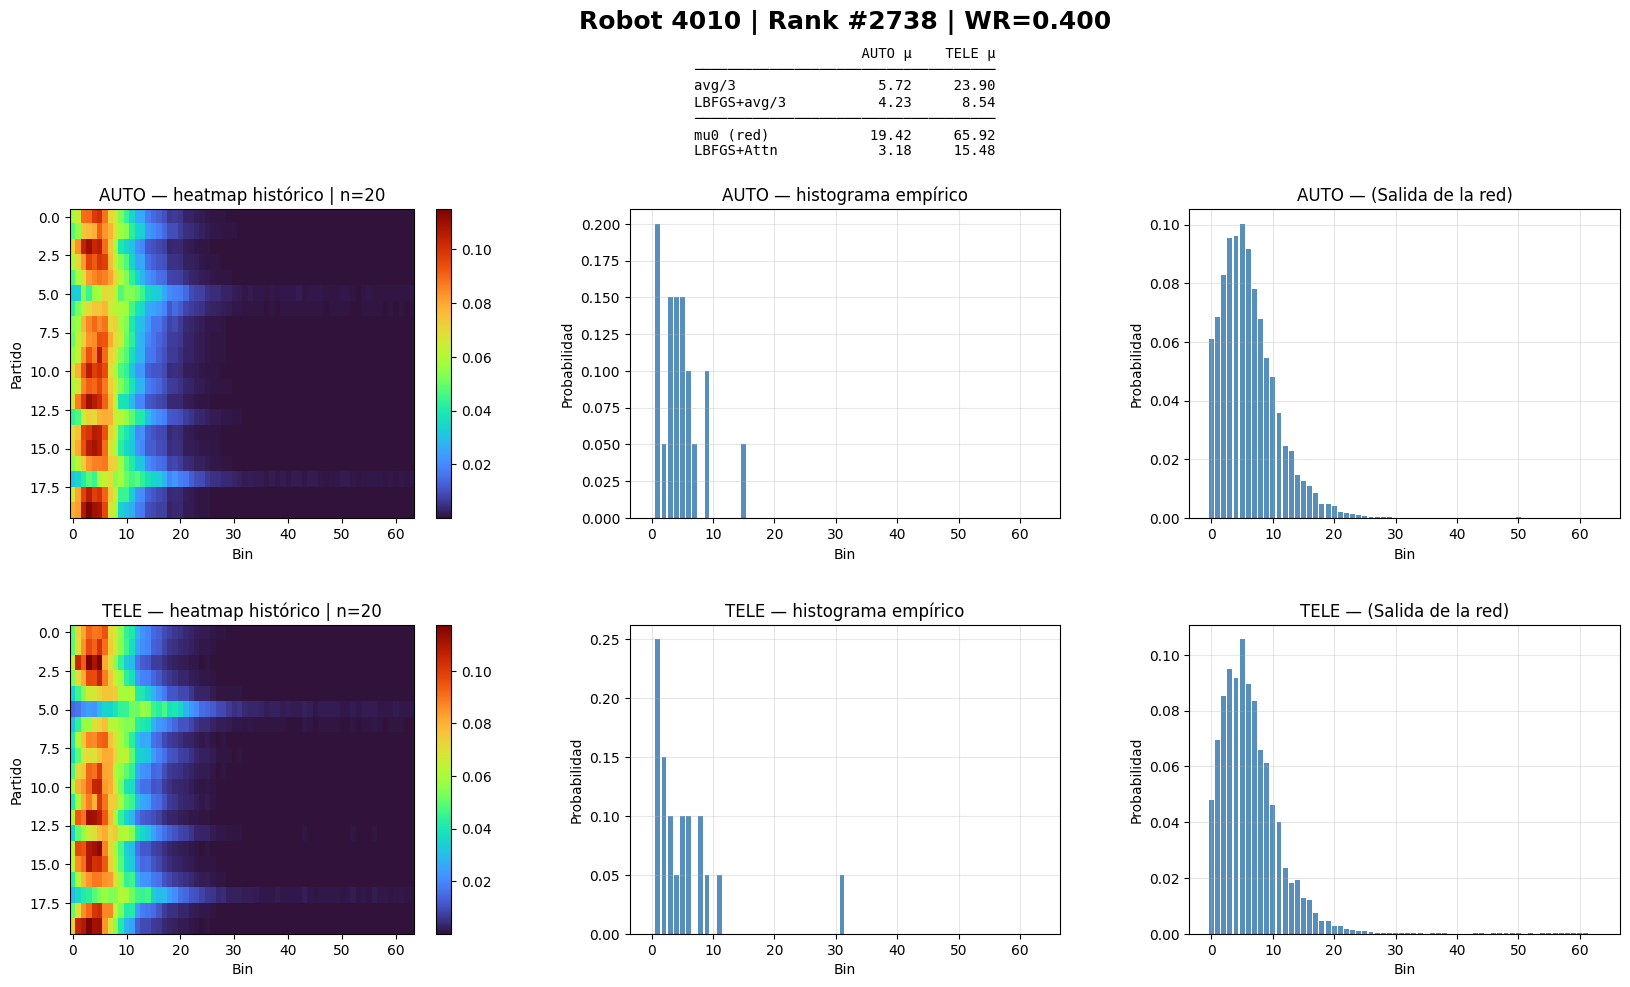

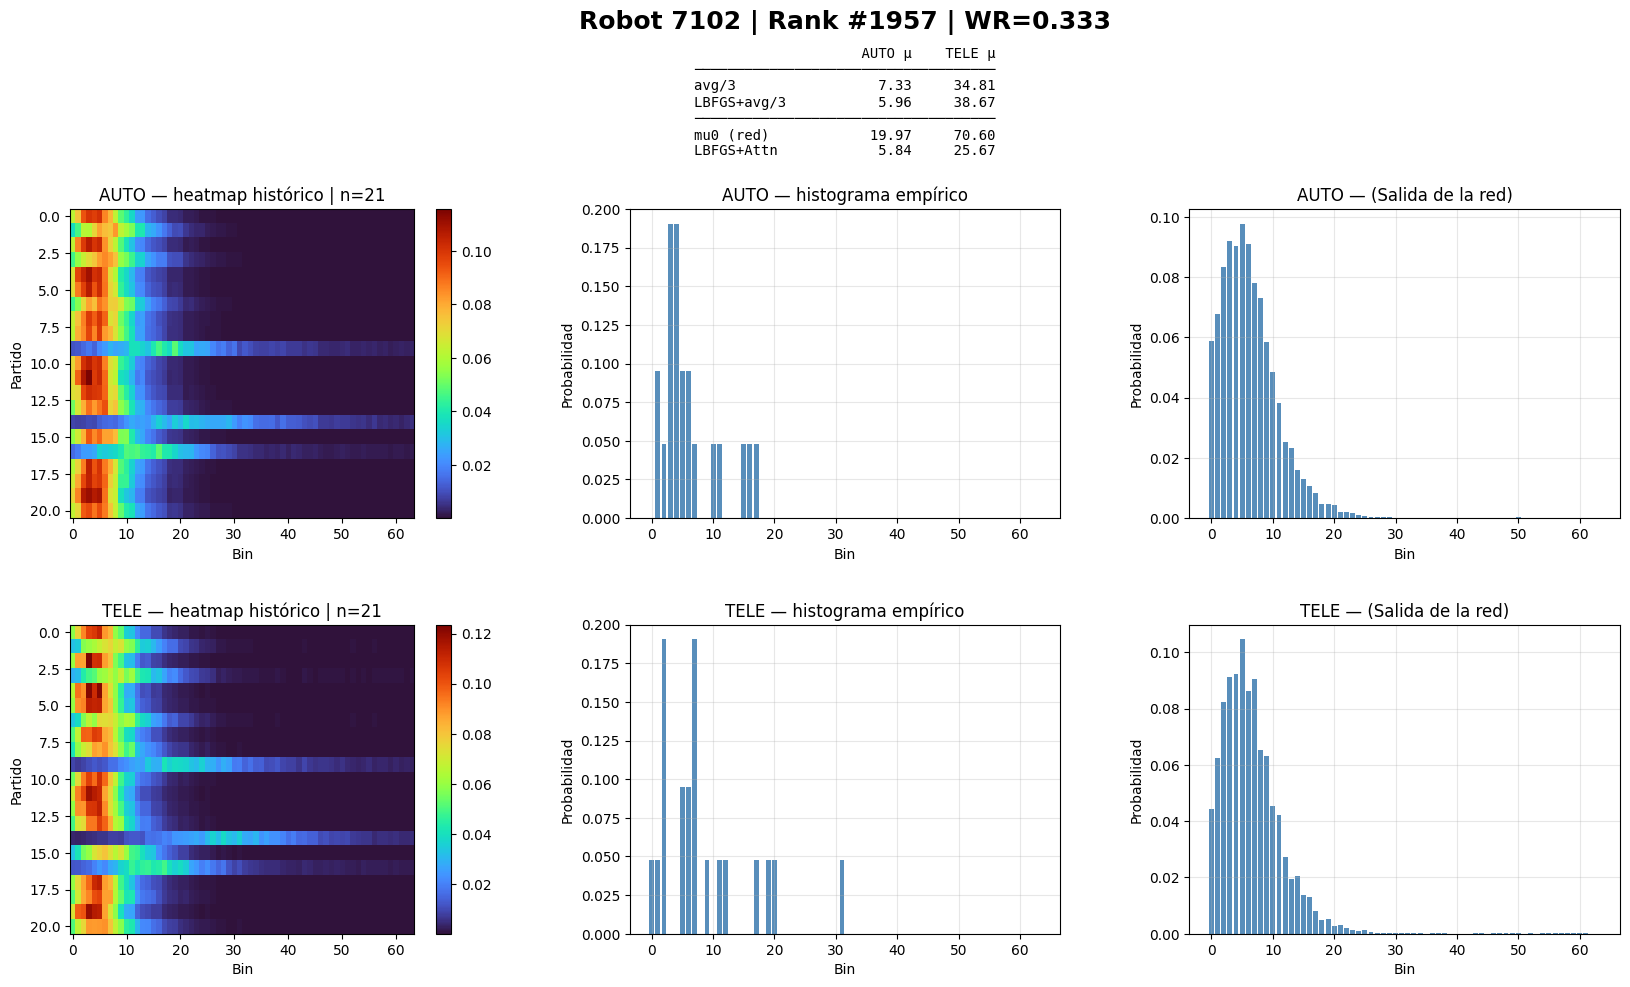

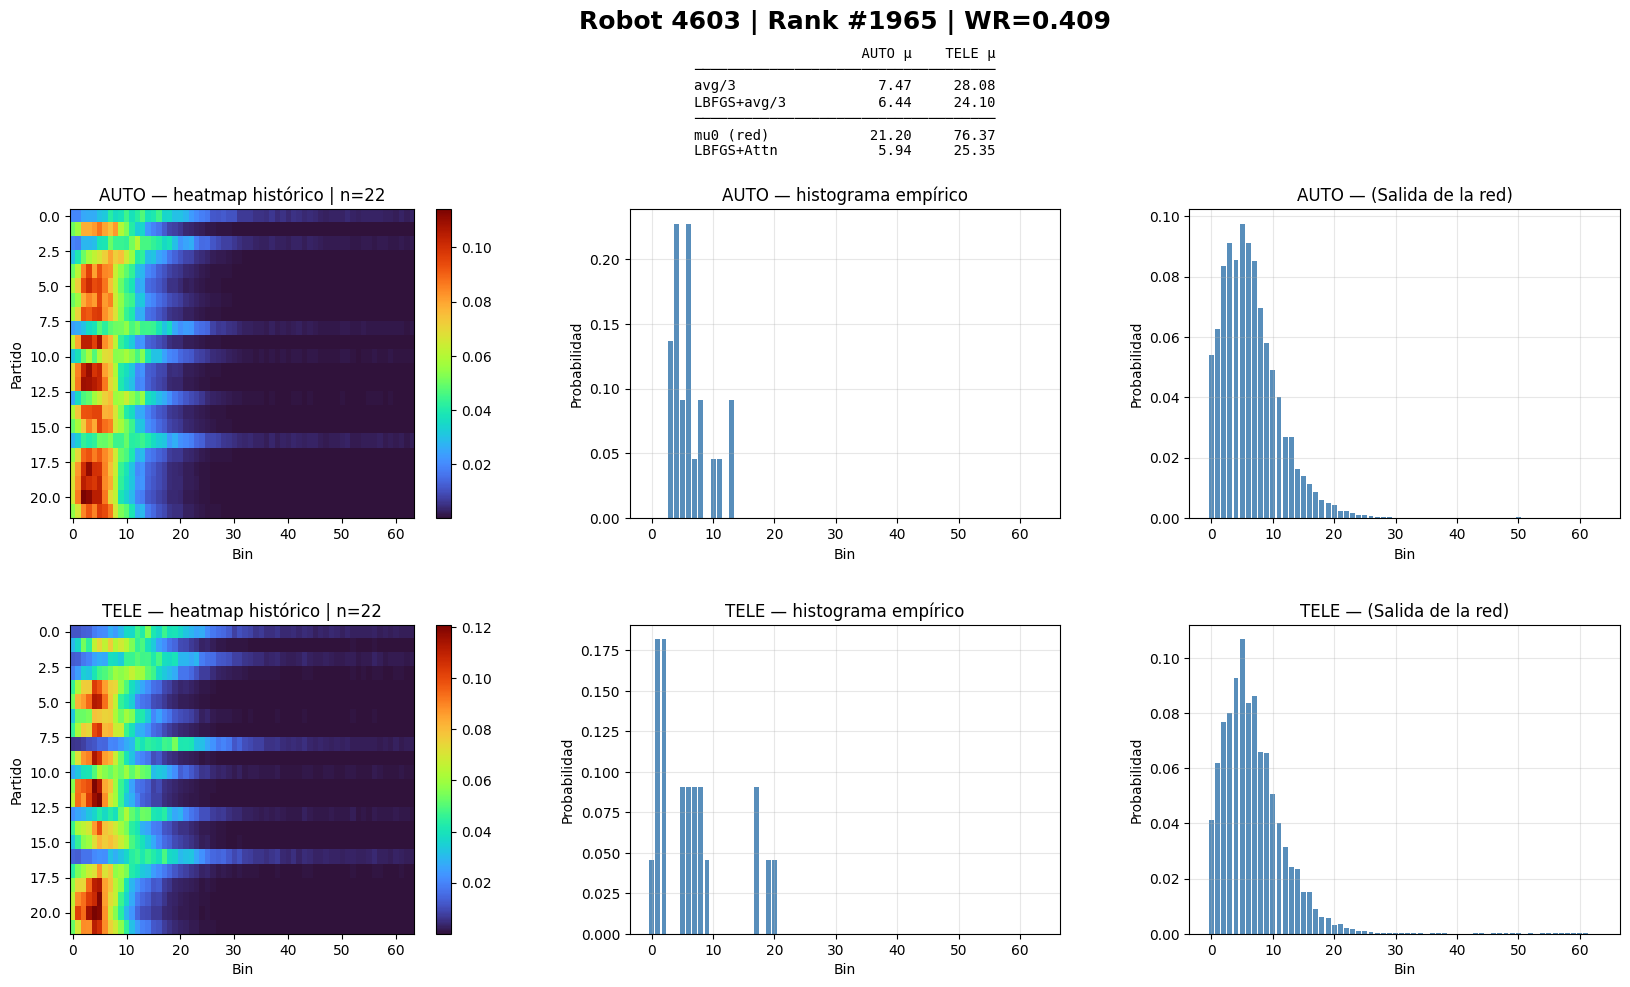

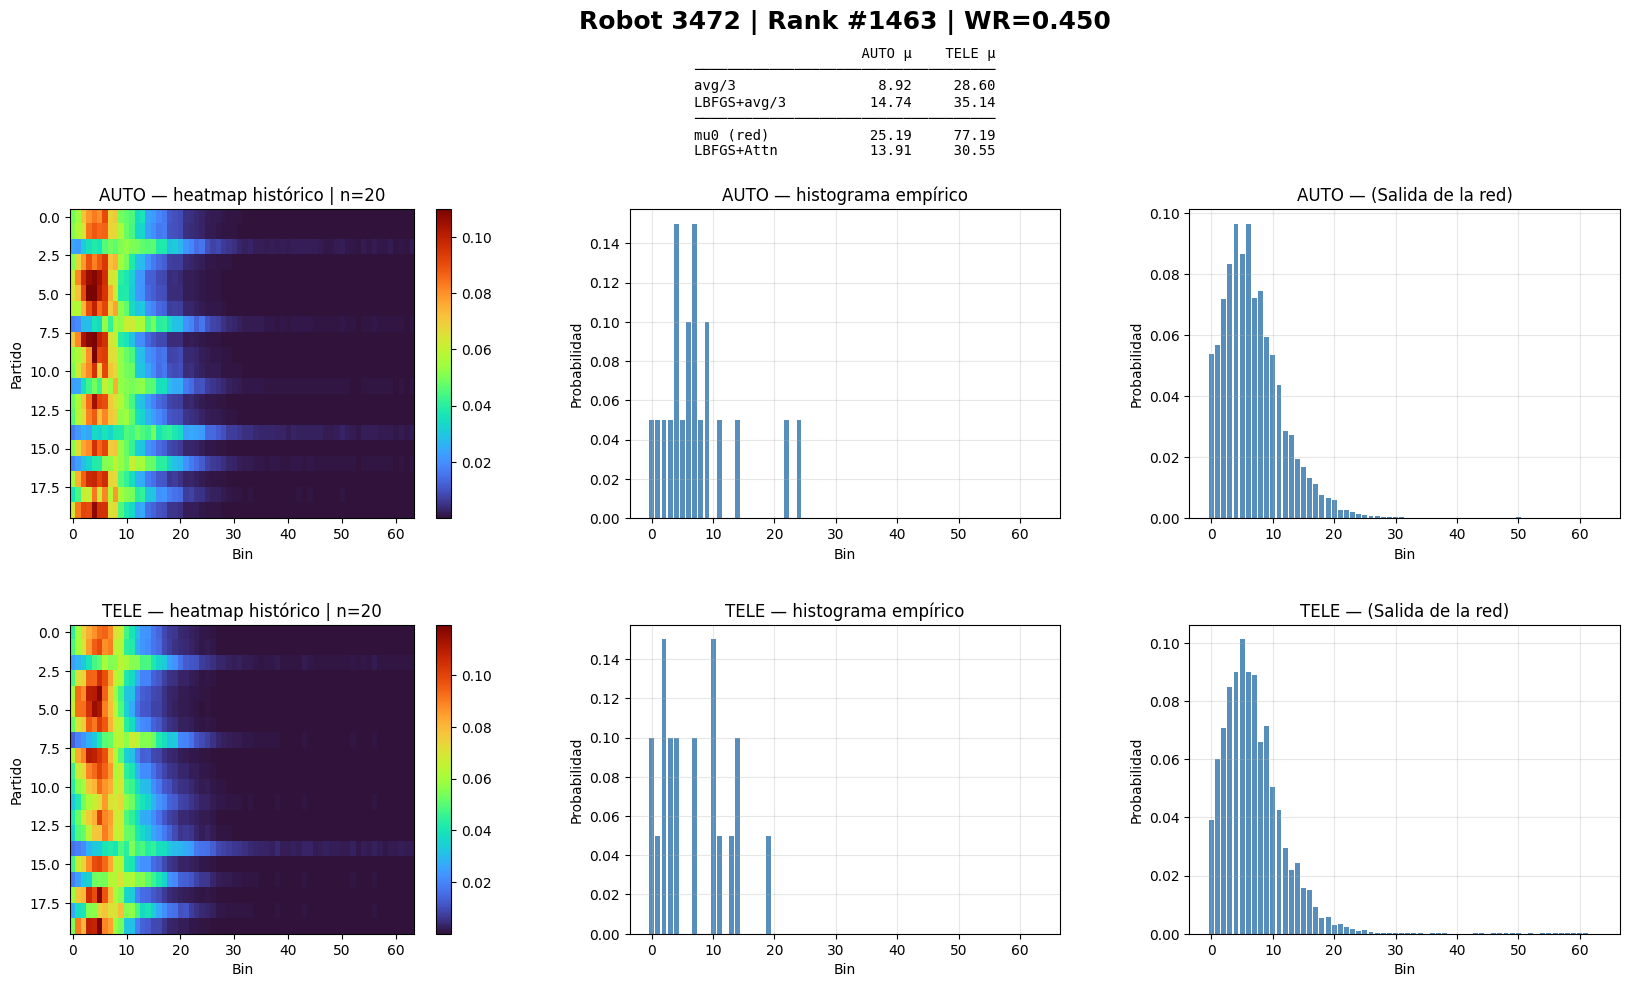

In [ ]:
robots = [254, 4414, 6017, 3478, 7421, 6170, 4010, 7102, 4603, 3472]
bins_arr = np.arange(N_BINS)

target_min_auto_pts = df_pre_auto['Y_auto'].min()
target_max_auto_pts = df_pre_auto['Y_auto'].max()
target_min_tele_pts = df_pre_tele['Y_tele'].min()
target_max_tele_pts = df_pre_tele['Y_tele'].max()

target_max_auto_pts_bronce = df_pre_bronce['totalAutoPoints'].max()
target_max_tele_pts_bronce = df_pre_bronce['totalTeleopPoints'].max()

mu0_auto_series = df_epa_auto.groupby('robot')['mu0'].mean() * target_max_auto_pts_bronce
mu0_tele_series = df_epa_tele.groupby('robot')['mu0'].mean() * target_max_tele_pts_bronce
mu0_total       = (mu0_auto_series + mu0_tele_series).sort_values(ascending=False)

epa_total = (df_epa_auto.groupby('robot')['EPA_map'].mean() +
             df_epa_tele.groupby('robot')['EPA_map'].mean()).sort_values(ascending=False)

rank_dict = {robot: i+1 for i, robot in enumerate(epa_total.index)}

for ROBOT_ID in robots:

    fig = plt.figure(figsize=(20, 12))
    gs  = fig.add_gridspec(3, 3, height_ratios=[0.3, 1, 1], hspace=0.45, wspace=0.3)

    # ── fila 0: título + tabla ────────────────────────────────────────
    avg_auto  = avg_auto_dict.get(ROBOT_ID, 0.0) / 3.0
    avg_tele  = avg_tele_dict.get(ROBOT_ID, 0.0) / 3.0
    win_rate  = win_rate_global.get(ROBOT_ID, 0.0)
    rank      = rank_dict.get(str(ROBOT_ID), 'N/A')

    epa_net_auto = df_epa_auto.groupby('robot')['EPA_map'].mean().get(str(ROBOT_ID), 0.0)
    epa_net_tele = df_epa_tele.groupby('robot')['EPA_map'].mean().get(str(ROBOT_ID), 0.0)
    std_net_auto = df_epa_auto.groupby('robot')['std_post'].mean().get(str(ROBOT_ID), 0.0)
    std_net_tele = df_epa_tele.groupby('robot')['std_post'].mean().get(str(ROBOT_ID), 0.0)

    epa_avg_auto = df_epa_auto_avg.groupby('robot')['EPA_map'].mean().get(str(ROBOT_ID), 0.0)
    epa_avg_tele = df_epa_tele_avg.groupby('robot')['EPA_map'].mean().get(str(ROBOT_ID), 0.0)
    std_avg_auto = df_epa_auto_avg.groupby('robot')['std_post'].mean().get(str(ROBOT_ID), 0.0)
    std_avg_tele = df_epa_tele_avg.groupby('robot')['std_post'].mean().get(str(ROBOT_ID), 0.0)

    mu0_auto = mu0_auto_series.get(str(ROBOT_ID), 0.0)
    mu0_tele = mu0_tele_series.get(str(ROBOT_ID), 0.0)

    tau_auto = df_epa_auto.groupby('robot')['tau'].mean().get(str(ROBOT_ID), 0.0)
    tau_tele = df_epa_tele.groupby('robot')['tau'].mean().get(str(ROBOT_ID), 0.0)

    table_text = (
        f"{'':16} {'AUTO μ':>9} {'TELE μ':>9}\n"
        f"{'─'*36}\n"
        f"{'avg/3':16} {avg_auto:>9.2f} {avg_tele:>9.2f}\n"
        f"{'LBFGS+avg/3':16} {epa_avg_auto:>9.2f} {epa_avg_tele:>9.2f}\n"
        f"{'─'*36}\n"
        f"{'mu0 (red)':16} {mu0_auto:>9.2f} {mu0_tele:>9.2f}\n"
        f"{'LBFGS+Attn':16} {epa_net_auto:>9.2f} {epa_net_tele:>9.2f}\n"
    )


    ax_table = fig.add_subplot(gs[0, :])
    ax_table.axis('off')
    ax_table.text(0.5, 1.0, f'Robot {ROBOT_ID} | Rank #{rank} | WR={win_rate:.3f}',
                  fontsize=18, ha='center', va='top', transform=ax_table.transAxes,
                  fontweight='bold')
    ax_table.text(0.5, 0.6, table_text, fontsize=10, ha='center', va='top',
                  fontfamily='monospace', transform=ax_table.transAxes)

    # ── filas 1 y 2: plots ────────────────────────────────────────────
    axes = np.array([[fig.add_subplot(gs[row+1, col]) for col in range(3)] for row in range(2)])

    for row_idx, (df_pre, col_pts, t_min, t_max, robot_vectors, model, name) in enumerate([
        (df_pre_auto, 'Y_auto', target_min_auto_pts, target_max_auto_pts, robot_vectors_auto, model_auto, 'AUTO'),
        (df_pre_tele, 'Y_tele', target_min_tele_pts, target_max_tele_pts, robot_vectors_tele, model_tele, 'TELE'),
    ]):
        matches = df_pre[
            (df_pre['X1_1'] == ROBOT_ID) |
            (df_pre['X1_2'] == ROBOT_ID) |
            (df_pre['X1_3'] == ROBOT_ID)
        ].reset_index(drop=True)

        n_matches = len(matches)
        heatmap   = np.zeros((n_matches, N_BINS))

        model.eval()
        with torch.no_grad():
            for i, (_, r) in enumerate(matches.iterrows()):
                v1 = robot_vectors[robot2idx[r['X1_1']]].unsqueeze(0).to(device)
                v2 = robot_vectors[robot2idx[r['X1_2']]].unsqueeze(0).to(device)
                v3 = robot_vectors[robot2idx[r['X1_3']]].unsqueeze(0).to(device)
                logits, _ = model([v1, v2, v3])
                heatmap[i] = torch.softmax(logits, dim=-1).cpu().numpy()[0]

        ax0 = axes[row_idx, 0]
        im  = ax0.imshow(heatmap, aspect='auto', cmap='turbo', interpolation='nearest')
        ax0.set_title(f'{name} — heatmap histórico | n={n_matches}')
        ax0.set_xlabel('Bin')
        ax0.set_ylabel('Partido')
        plt.colorbar(im, ax=ax0)

        vals     = matches[col_pts].values
        pts_norm = (vals - t_min) / (t_max - t_min + 1e-8)
        bin_idxs = np.clip(np.floor(pts_norm * N_BINS).astype(int), 0, N_BINS - 1)
        hist     = np.zeros(N_BINS)
        for b in bin_idxs:
            hist[b] += 1
        hist = hist / hist.sum() if hist.sum() > 0 else hist

        ax1 = axes[row_idx, 1]
        ax1.bar(bins_arr, hist, color='steelblue', alpha=0.9)
        ax1.set_title(f'{name} — histograma empírico')
        ax1.set_xlabel('Bin')
        ax1.set_ylabel('Probabilidad')
        ax1.grid(alpha=0.3)

        ax2       = axes[row_idx, 2]
        robot_idx = robot2idx[ROBOT_ID]
        v         = robot_vectors[robot_idx].unsqueeze(0).to(device)
        mean_vec  = robot_vectors.mean(dim=0, keepdim=True).to(device)
        with torch.no_grad():
            logits, _ = model([v, mean_vec, mean_vec])
            probs_prior = torch.softmax(logits, dim=-1).cpu().numpy()[0]
        ax2.bar(bins_arr, probs_prior, color='steelblue', alpha=0.9)
        ax2.set_title(f'{name} — (Salida de la red)')
        ax2.set_xlabel('Bin')
        ax2.set_ylabel('Probabilidad')
        ax2.grid(alpha=0.3)

    plt.show()

In [ ]:
print(f'avg_auto mean: {np.mean(list(avg_auto_dict.values())):.2f}')
print(f'avg_tele mean: {np.mean(list(avg_tele_dict.values())):.2f}')
print(f'lookup_avg epa_total mean: {lookup_avg["epa_total"].mean():.2f}')
print(f'lookup_net epa_total mean: {lookup_net["epa_total"].mean():.2f}')
print(f'Score real mean: {df_mundial_bronce["Score"].mean():.2f}')
print(f'totalAutoPoints mean: {df_mundial_bronce["totalAutoPoints"].mean():.2f}')
print(f'totalTeleopPoints mean: {df_mundial_bronce["totalTeleopPoints"].mean():.2f}')
print(f'EPA=0 en auto: {(df_epa_auto["EPA_map"]==0).mean():.3f}')
print(f'EPA=0 en tele: {(df_epa_tele["EPA_map"]==0).mean():.3f}')

avg_auto mean: 32.58
avg_tele mean: 123.57
lookup_avg epa_total mean: 58.26
lookup_net epa_total mean: 55.15
Score real mean: 416.40
totalAutoPoints mean: 82.79
totalTeleopPoints mean: 325.69
EPA=0 en auto: 0.008
EPA=0 en tele: 0.041


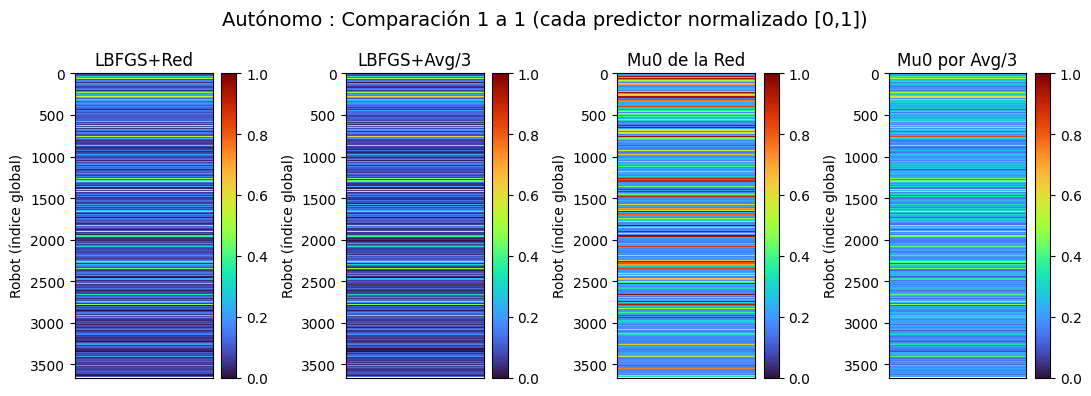

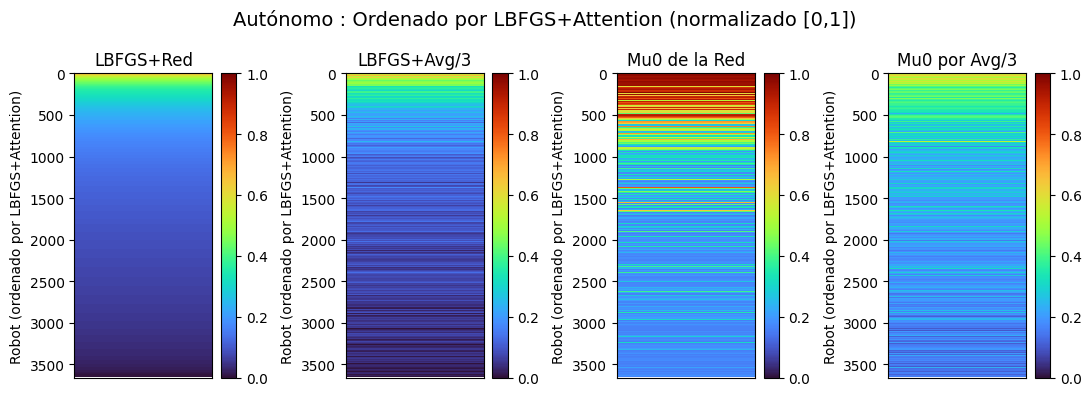

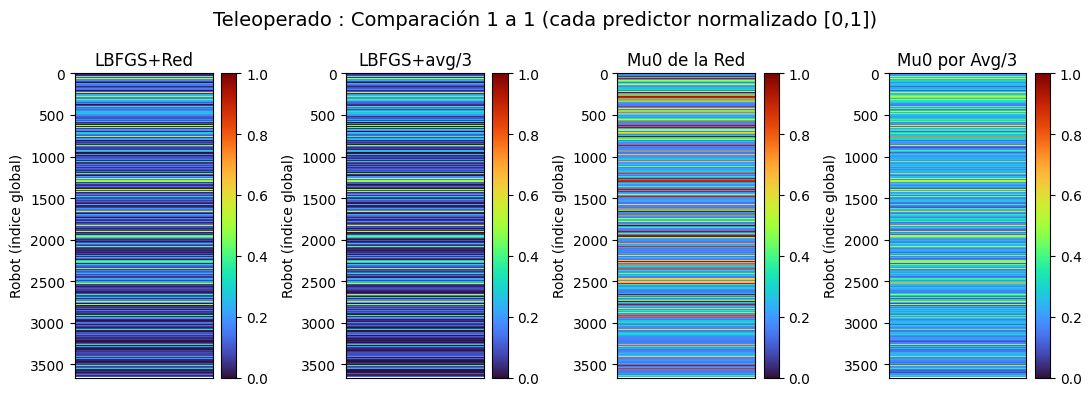

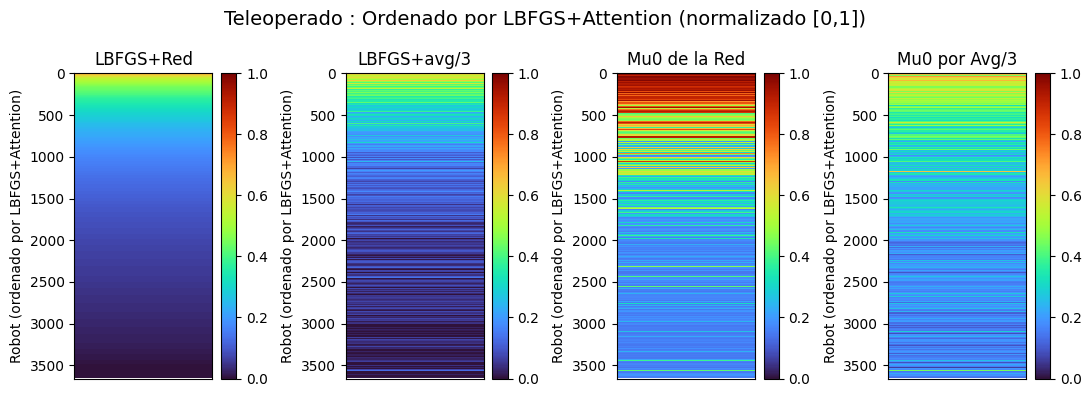

In [ ]:
robots_list = [str(r) for r in todos_robots]

baseline_auto = pd.Series({str(r): avg_auto_dict.get(r, 0.0) / 3.0 for r in todos_robots})
baseline_tele = pd.Series({str(r): avg_tele_dict.get(r, 0.0) / 3.0 for r in todos_robots})

for componente, pairs in [
    ('Autónomo', [
        (df_epa_auto.groupby('robot')['EPA_map'].mean(),     'LBFGS+Red'),
        (df_epa_auto_avg.groupby('robot')['EPA_map'].mean(), 'LBFGS+Avg/3'),
        (df_epa_auto.groupby('robot')['mu0'].mean(),         'Mu0 de la Red'),
        (baseline_auto.reindex(robots_list).fillna(0),       'Mu0 por Avg/3'),
    ]),
    ('Teleoperado', [
        (df_epa_tele.groupby('robot')['EPA_map'].mean(),     'LBFGS+Red'),
        (df_epa_tele_avg.groupby('robot')['EPA_map'].mean(), 'LBFGS+avg/3'),
        (df_epa_tele.groupby('robot')['mu0'].mean(),         'Mu0 de la Red'),
        (baseline_tele.reindex(robots_list).fillna(0),       'Mu0 por Avg/3'),
    ]),
]:
    all_vals = []
    labels   = []
    for series, label in pairs:
        combined = series.reindex(robots_list).fillna(0).values
        vmin, vmax = combined.min(), combined.max()
        combined = (combined - vmin) / (vmax - vmin + 1e-8)
        all_vals.append(combined)
        labels.append(label)

    order = np.argsort(all_vals[0])[::-1]

    for ordenado, fname in [
        (False, f'heatmap_{componente.lower()}_comparacion.png'),
        (True,  f'heatmap_{componente.lower()}_comparacion_sorted.png'),
    ]:
        fig, axes = plt.subplots(1, 4, figsize=(11, 4))

        for ax, label, vals in zip(axes, labels, all_vals):
            v = vals[order] if ordenado else vals
            im = ax.imshow(v.reshape(-1, 1), aspect='auto', cmap='turbo',
                           interpolation='nearest', vmin=0, vmax=1)
            ax.set_title(label)
            ax.set_xlabel(f'')
            ax.set_ylabel('Robot (ordenado por LBFGS+Attention)' if ordenado else 'Robot (índice global)')
            ax.set_xticks([])
            plt.colorbar(im, ax=ax)

        titulo = (f'{componente} : Ordenado por LBFGS+Attention (normalizado [0,1])'
                  if ordenado else
                  f'{componente} : Comparación 1 a 1 (cada predictor normalizado [0,1])')
        plt.suptitle(titulo, fontsize=14)
        plt.tight_layout()
        plt.savefig(fname, dpi=150, bbox_inches='tight')
        plt.show()

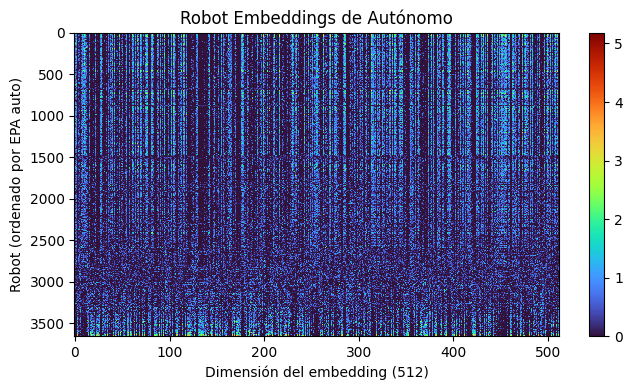

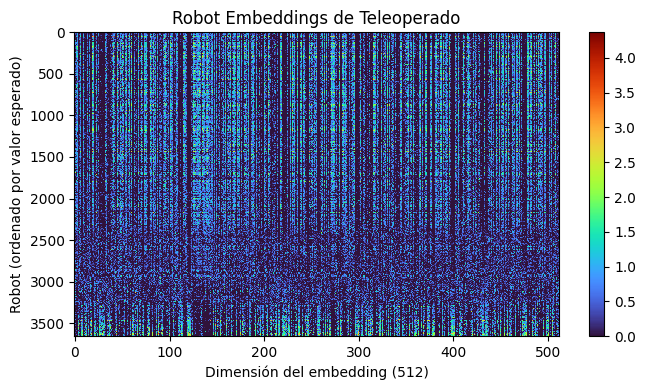

In [ ]:
model_auto.eval()
with torch.no_grad():
    embeddings_auto = model_auto.encode_robot(robot_vectors_auto.to(device)).cpu().numpy()

epa_order_auto = np.array([
    lookup_net.loc[str(r), 'epa_auto'] if str(r) in lookup_net.index else 0.0
    for r in todos_robots
])
sorted_idx_auto = np.argsort(epa_order_auto)
emb_sorted_auto = embeddings_auto[sorted_idx_auto]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(emb_sorted_auto, aspect='auto', cmap='turbo', interpolation='nearest')
ax.set_xlabel('Dimensión del embedding (512)')
ax.set_ylabel('Robot (ordenado por EPA auto)')
ax.set_title('Robot Embeddings de Autónomo')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('robot_embeddings_auto.png', dpi=150, bbox_inches='tight')
plt.show()

model_tele.eval()
with torch.no_grad():
    embeddings_tele = model_tele.encode_robot(robot_vectors_tele.to(device)).cpu().numpy()

epa_order_tele = np.array([
    lookup_net.loc[str(r), 'epa_tele'] if str(r) in lookup_net.index else 0.0
    for r in todos_robots
])
sorted_idx_tele = np.argsort(epa_order_tele)
emb_sorted_tele = embeddings_tele[sorted_idx_tele]

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(emb_sorted_tele, aspect='auto', cmap='turbo', interpolation='nearest')
ax.set_xlabel('Dimensión del embedding (512)')
ax.set_ylabel('Robot (ordenado por valor esperado)')
ax.set_title('Robot Embeddings de Teleoperado')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('robot_embeddings_tele.png', dpi=150, bbox_inches='tight')
plt.show()

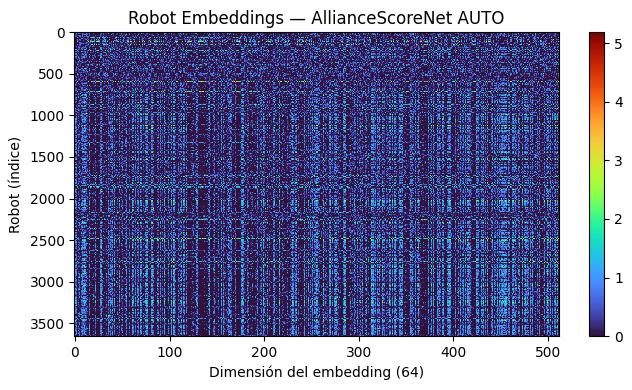

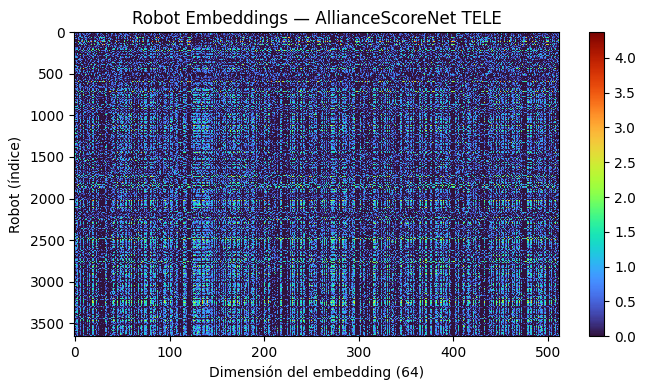

In [ ]:
model_auto.eval()
with torch.no_grad():
    embeddings_auto = model_auto.encode_robot(robot_vectors_auto.to(device)).cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(embeddings_auto, aspect='auto', cmap='turbo', interpolation='nearest')
ax.set_xlabel('Dimensión del embedding (64)')
ax.set_ylabel('Robot (índice)')
ax.set_title('Robot Embeddings — AllianceScoreNet AUTO')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('robot_embeddings_auto.png', dpi=150, bbox_inches='tight')
plt.show()

model_tele.eval()
with torch.no_grad():
    embeddings_tele = model_tele.encode_robot(robot_vectors_tele.to(device)).cpu().numpy()

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(embeddings_tele, aspect='auto', cmap='turbo', interpolation='nearest')
ax.set_xlabel('Dimensión del embedding (64)')
ax.set_ylabel('Robot (índice)')
ax.set_title('Robot Embeddings — AllianceScoreNet TELE')
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig('robot_embeddings_tele.png', dpi=150, bbox_inches='tight')
plt.show()